# Analyse de Données de Log de Signaux

Ce notebook Jupyter a pour but de vous guider à travers les différentes étapes de l'analyse de données de signaux. Il utilise le module Python `data_processor.py` pour séparer la logique de préparation des données de l'analyse elle-même.

1. Figer une methode de fenêtrage
2. Tracer les pressions par fenêtre / 

## Étape 1 : Lecture et préparation des fichiers de log

Nous allons utiliser la fonction `process_logs()` du module `data_processor` pour lire le fichier JSON et ses logs BLF associés. Le DataFrame combiné sera ensuite sauvegardé au format Parquet pour une utilisation ultérieure. Cette approche permet une exécution en mode 'headless' du script si nécessaire.

In [1]:
PLOT_DETAIL = False

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import os

# Import du module personnalisé
import data_processor


In [3]:

# from ..services.digital_twin_service.excavator_model import Excavator

# Définition des chemins de fichiers
# root_path = os.path.join(os.path.dirname(__file__), '..')
datas_path = "datas"
app_log_dir_path = os.path.join(datas_path, 'app_logs')
# json_file_path = os.path.join(root_path, 'app_logs', 'app_log_20250820_144810-example.json')
can_log_dir_path = os.path.join(datas_path, 'can_logs')
dbc_dir_path = "../config"
output_parquet_path = os.path.join(datas_path, 'analysis', 'decoded_signals.parquet')

target_value_column = "hardness"

# Source - https://stackoverflow.com/questions/25351968/how-can-i-display-full-non-truncated-dataframe-information-in-html-when-conver
# Posted by Benjamin Ziepert
# Retrieved 05/11/2025, License - CC-BY-SA 4.0

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)




# Traitement des données via le module externe
df_org, my_excavator, sensor_state = data_processor.process_logs(app_log_dir_path, can_log_dir_path, dbc_dir_path)

if df_org is not None and not df_org.empty:
    # Sauvegarde du DataFrame en fichier Parquet
    df_org.to_parquet(output_parquet_path)
    print(f"Données combinées sauvegardées dans '{output_parquet_path}'.")

    print("\nAperçu des 5 premières lignes du DataFrame final :")
    print(df_org.head())
    print("\nInformations sur le DataFrame final :")
    df_org.info()
    print(f"Col={df_org.columns}")

    # Visualisation initiale des signaux (exemple sur les colonnes numériques)
    # df_full.select_dtypes(include=np.number).plot(figsize=(12, 6), title="Visualisation Initiale des Signaux", marker=".")
    # # plt.xlabel("timestamp")
    # plt.ylabel("Valeur du Signal")
    # plt.legend()
    # plt.show()
else:
    print("Échec du traitement des fichiers. Le reste du notebook ne peut pas s'exécuter.")

Fichier JSON datas\app_logs\C16-2-3-4_app_log_20251030_Merge.json de session lu avec succès.
Fichier DBC chargé avec succès.
C16-2-3-4 at 16.0
Décodage du fichier BLF: datas\can_logs\app_log_20251030_122610.blf
Décodage du fichier BLF: datas\can_logs\app_log_20251030_123548.blf
Décodage du fichier BLF: datas\can_logs\app_log_20251030_124221.blf
Tous les fichiers BLF ont été décodés et concaténés.
Loading DBC file from ../config\db-full-v3.dbc...
Initialized sensor state with 153 signals.
Fichier JSON datas\app_logs\C25-2_app_log_20251030_143130.json de session lu avec succès.
Fichier DBC chargé avec succès.
C25-2 at 25.0
Décodage du fichier BLF: datas\can_logs\app_log_20251030_143130.blf
Tous les fichiers BLF ont été décodés et concaténés.
Loading DBC file from ../config\db-full-v3.dbc...
Initialized sensor state with 153 signals.
Fichier JSON datas\app_logs\C30-2_app_log_20251030_152900.json de session lu avec succès.
Fichier DBC chargé avec succès.
C30-2 at 30.0
Décodage du fichier B

# Adjust timeserie index

In [4]:
df_full = df_org

In [5]:
# Save original timstamp in 'ts' column
df_full["ts"] = df_full.index

C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\1973844596.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full["ts"] = df_full.index


In [6]:
df_full.sort_index(inplace=True)
df_full.index = pd.to_datetime(df_full.index, unit='s', origin="unix")

In [7]:
df_full["delta_ts"] = df_full.index - df_full.index[0]
df_full["delta_ts"] = pd.to_timedelta(df_full["delta_ts"], unit='seconds')

C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\1401976158.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full["delta_ts"] = df_full.index - df_full.index[0]


# Some generic methods

In [8]:
def displaySig(title, df, sigList, subp:str|list="auto", hlines=[], legend=[]):
    hsize = len(sigList) + 7
    if subp=="auto" :
        sub = [[el] for el in sigList]
        df[sigList].plot(figsize=(12, hsize), title=title, subplots=sub, grid=True)
    elif len(subp) > 0 :
        df[sigList].plot(figsize=(12, hsize), title=title, subplots=subp, grid=True)
    else:
        df[sigList].plot(figsize=(12, hsize), title=title, grid=True)
    for val in hlines:
        plt.axhline(val)
    # plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M:%S"))
    # plt.legend(legend)
    plt.show()

In [9]:
# sensor_state

def compute_digital_twin(df:pd.DataFrame, excavator):
    # for index, row in df.iterrows():
    #     excavator.update_from_sensors(row)
        # print(excavator.get_parts_kinematics())
        # df.at[index, name_state] = 1
    new_val = df.apply(excavator.update_and_get_kinematics, axis=1, result_type='expand')

    dfnew = pd.concat([df, new_val], axis=1)
    return dfnew, new_val

# Remove unecessary signals

In [10]:
# Remove unused signals
sig_suffix = ["QuatX",
              "QuatY",
              "QuatZ",
              "QuatW",
              "LinAccX",
              "LinAccY",
              "LinAccZ",
            #   "InclX",
            #   "InclY",
            #   "InclZ",
              "AccX",
              "AccY",
              "AccZ",
              "AccAF",
            #   "GravityX",
            #   "GravityY",
            #   "GravityZ",
              "EulerX",
              "EulerY",
              "EulerZ",
              "EulerAF",
              "EulerGF"
              ]

elts = ["TURRET", "BOOM", "JIB", "BUCKET"]

unused_signals = []
for e in elts:
    for s in sig_suffix:
        unused_signals.append(f"PF_{e}_{s}")

# unused_signals = ["PF_BOOM_QuatX",
#                   "PF_BOOM_QuatY",
#                   "PF_BOOM_QuatZ",
#                   "PF_BOOM_QuatW",
#                   "PF_TURRET_QuatX",
#                   "PF_TURRET_QuatY",
#                   "PF_TURRET_QuatZ",
#                   "PF_TURRET_QuatW",
#                   "PF_JIB_QuatX",
#                   "PF_JIB_QuatY",
#                   "PF_JIB_QuatZ",
#                   "PF_JIB_QuatW",
#                   "PF_BUCKET_QuatX",
#                   "PF_BUCKET_QuatY",
#                   "PF_BUCKET_QuatZ",
#                   "PF_BUCKET_QuatW",
#                   "PF_BUCKET_LinAccX",
#                   "PF_BUCKET_LinAccY",
#                   "PF_BUCKET_LinAccZ",
#                   "PF_BUCKET_LinAccX",
#                   ]

In [11]:
cols = df_full.columns
for c in unused_signals:
    if c not in cols :
        print(f"{c} Not in columns")

In [12]:
df_full.drop(columns=unused_signals, inplace=True)

# Fill missing values

In [13]:
# Vérification et gestion des valeurs manquantes
print("\nNombre de valeurs manquantes par colonne :")
print(df_full.isnull().sum())

# Remplissage des valeurs manquantes avec la moyenne de la colonne
# df.fillna(method='ffill', inplace=True)
df_full.ffill(inplace=True)

# Remplissage des valeurs manquantes restantes (au début du DataFrame)
# df_full.fillna(0, inplace=True)
df_full.bfill(inplace=True)

print("\nValeurs manquantes après remplissage :")
print(df_full.isnull().sum())


Nombre de valeurs manquantes par colonne :
A5_BUCKET_HP_b           326964
A6_BUCKET_BP_b           326964
A7                       326964
A8                       326964
PF_TURRET_PFAngX         367425
PF_TURRET_PFAngY         367425
PF_TURRET_PFAngZ         367425
PF_TURRET_PFAngAF        367425
PF_TURRET_PFAngGF        367425
A1_BOOM_HP_b             326039
A2_BOOM_BP_b             326039
A3_JIB_HP_b              326039
A4_JIB_BP_b              326039
PF_BOOM_RotRateX         365944
PF_BOOM_RotRateY         365944
PF_BOOM_RotRateZ         365944
PF_BOOM_RotRateAF        365944
PF_BOOM_AccRotRateX      366166
PF_BOOM_AccRotRateY      366166
PF_BOOM_AccRotRateZ      366166
PF_BOOM_PFAngX           366640
PF_BOOM_PFAngY           366640
PF_BOOM_PFAngZ           366640
PF_BOOM_PFAngAF          366640
PF_BOOM_PFAngGF          366640
PF_BUCKET_RotRateX       366878
PF_BUCKET_RotRateY       366878
PF_BUCKET_RotRateZ       366878
PF_BUCKET_RotRateAF      366878
PF_BUCKET_AccRotRateX    367

## Calcul de la géométrie de la machine

In [14]:
df_full, new_val = compute_digital_twin(df_full, my_excavator)

# Resample to 10ms

In [15]:
df_full = df_full.resample("10ms").bfill()

# Generics methods

## Compute Diff, Rolling Mean...

In [81]:
# Define the sample period and cutoff frequency

# Calculate the average time difference between consecutive timestamps = Estimation de la période d'échantillonage
average_time_difference = df_full.index.diff().mean().total_seconds()
sample_period = average_time_difference # 0.01  # Sample period in seconds (10 ms)

cutoff = 0.4  # Cutoff frequency in Hz

# Calculate the window size for rolling mean
window_size = int(np.round(cutoff / sample_period))
window_size

40

In [82]:
def diff_computation(df, d_name, window_mean):
    # Compute MeanRoll
    name_roll = d_name + "_roll"
    df[name_roll] = df[d_name].rolling(window=window_mean, center=True).mean()

    # Compute diff between consecutive values
    diff_name = d_name +"_diff"
    df[diff_name] = df[d_name].diff()

    diff_name_roll = diff_name + "_roll"
    df[diff_name_roll] = df[diff_name].rolling(window=window_mean, center=True).mean()


    # 2nd diff : 2nd order gradient
    diff_diff_name = diff_name_roll +"_diff"
    df[diff_diff_name] = df[diff_name_roll].diff()
    diff_diff_name_roll = diff_diff_name + "_roll"
    df[diff_diff_name_roll] = df[diff_diff_name].rolling(window=window_mean, center=True).mean()

    return name_roll, diff_name, diff_name_roll, diff_diff_name, diff_diff_name_roll

## Compute new values : pressures, delta angles...

In [83]:
# Use standard "Gain Annulaire"
GA = 0.75

# Compute Pressure delta : HP-BP
df_full["compute_BOOM_Press"] = df_full.A1_BOOM_HP_b - GA*df_full.A2_BOOM_BP_b
df_full["compute_JIB_Press"] = df_full.A3_JIB_HP_b - GA*df_full.A4_JIB_BP_b
df_full["compute_BUCKET_Press"] = df_full.A5_BUCKET_HP_b - GA*df_full.A6_BUCKET_BP_b

In [84]:
# Compute SUM of pressure
df_full["compute_sumBOOM_JIB_Press"] = df_full["compute_BOOM_Press"] + df_full["compute_JIB_Press"]
df_full["compute_sumAll_Press"] = df_full["compute_BOOM_Press"] + df_full["compute_JIB_Press"] + df_full["compute_BUCKET_Press"]

In [85]:
diff_computation(df_full, "compute_BOOM_Press", window_size)
diff_computation(df_full, "compute_JIB_Press", window_size)
diff_computation(df_full, "compute_BUCKET_Press", window_size)

diff_computation(df_full, "compute_sumBOOM_JIB_Press", window_size)
diff_computation(df_full, "compute_sumAll_Press", window_size)

('compute_sumAll_Press_roll',
 'compute_sumAll_Press_diff',
 'compute_sumAll_Press_diff_roll',
 'compute_sumAll_Press_diff_roll_diff',
 'compute_sumAll_Press_diff_roll_diff_roll')

In [86]:
# Filter pressures under usable values
# Boom No filter
# Jib P > 0
# Bucket P > 0

df_full["compute_JIB_Press_roll_Filter"] = df_full["compute_JIB_Press_roll"][df_full["compute_JIB_Press_roll"] > 0]
df_full["compute_BUCKET_Press_roll_Filter"] = df_full["compute_BUCKET_Press_roll"][df_full["compute_BUCKET_Press_roll"] > 0]

In [87]:
diff_computation(df_full, "compute_JIB_Press_roll_Filter", window_size)
diff_computation(df_full, "compute_BUCKET_Press_roll_Filter", window_size)

('compute_BUCKET_Press_roll_Filter_roll',
 'compute_BUCKET_Press_roll_Filter_diff',
 'compute_BUCKET_Press_roll_Filter_diff_roll',
 'compute_BUCKET_Press_roll_Filter_diff_roll_diff',
 'compute_BUCKET_Press_roll_Filter_diff_roll_diff_roll')

In [88]:
diff_computation(df_full, "PF_BOOM_PFAngZ", window_size)
diff_computation(df_full, "PF_JIB_PFAngZ", window_size)
diff_computation(df_full, "PF_BUCKET_PFAngX", window_size)

('PF_BUCKET_PFAngX_roll',
 'PF_BUCKET_PFAngX_diff',
 'PF_BUCKET_PFAngX_diff_roll',
 'PF_BUCKET_PFAngX_diff_roll_diff',
 'PF_BUCKET_PFAngX_diff_roll_diff_roll')

In [89]:
diff_computation(df_full, "PF_BOOM_RotRateZ", window_size)
diff_computation(df_full, "PF_JIB_RotRateZ", window_size)
diff_computation(df_full, "PF_BUCKET_RotRateX", 500)

('PF_BUCKET_RotRateX_roll',
 'PF_BUCKET_RotRateX_diff',
 'PF_BUCKET_RotRateX_diff_roll',
 'PF_BUCKET_RotRateX_diff_roll_diff',
 'PF_BUCKET_RotRateX_diff_roll_diff_roll')

In [90]:
diff_computation(df_full, "turret_pitch", window_size)
diff_computation(df_full, "boom_pitch", window_size)
diff_computation(df_full, "jib_pitch", window_size)
diff_computation(df_full, "bucket_pitch", window_size)

('bucket_pitch_roll',
 'bucket_pitch_diff',
 'bucket_pitch_diff_roll',
 'bucket_pitch_diff_roll_diff',
 'bucket_pitch_diff_roll_diff_roll')

In [91]:
# Compute Angle delta between elements

df_full["compute_TURRET_BOOM_angle"] = df_full.PF_TURRET_PFAngZ - df_full.PF_BOOM_PFAngZ
df_full["compute_BOOM_JIB_angle"] = df_full.PF_BOOM_PFAngZ - df_full.PF_JIB_PFAngZ
df_full["compute_JIB_BUCKET_angle"] = df_full.PF_JIB_PFAngZ - df_full.PF_BUCKET_PFAngX

In [92]:
# Compute Angle Rot Rate delta between elements

df_full["compute_TURRET_BOOM_RotRate"] = df_full.PF_TURRET_RotRateZ - df_full.PF_BOOM_RotRateZ
df_full["compute_BOOM_JIB_RotRate"] = df_full.PF_BOOM_RotRateZ - df_full.PF_JIB_RotRateZ
df_full["compute_JIB_BUCKET_RotRate"] = df_full.PF_JIB_RotRateZ - df_full.PF_BUCKET_RotRateX

In [93]:
diff_computation(df_full, "compute_TURRET_BOOM_angle", window_size)
diff_computation(df_full, "compute_BOOM_JIB_angle", window_size)
diff_computation(df_full, "compute_JIB_BUCKET_angle", window_size)

('compute_JIB_BUCKET_angle_roll',
 'compute_JIB_BUCKET_angle_diff',
 'compute_JIB_BUCKET_angle_diff_roll',
 'compute_JIB_BUCKET_angle_diff_roll_diff',
 'compute_JIB_BUCKET_angle_diff_roll_diff_roll')

In [94]:
diff_computation(df_full, "compute_TURRET_BOOM_RotRate", window_size)
diff_computation(df_full, "compute_BOOM_JIB_RotRate", window_size)
diff_computation(df_full, "compute_JIB_BUCKET_RotRate", window_size)

('compute_JIB_BUCKET_RotRate_roll',
 'compute_JIB_BUCKET_RotRate_diff',
 'compute_JIB_BUCKET_RotRate_diff_roll',
 'compute_JIB_BUCKET_RotRate_diff_roll_diff',
 'compute_JIB_BUCKET_RotRate_diff_roll_diff_roll')

# Detection

In [95]:
# Iterate over the rows and set the state and threshold values
def detect(df, name, up_limit, down_limit, th=None):
    name_state = name + "_state"
    df[name_state] = 0 # Initialize to 0

    if th is not None:
        threshold=0

        for index, row in df.iterrows():
            if row[name] > (up_limit - threshold):
                df.at[index, name_state] = 1
                threshold = th
            elif row[name] < (down_limit + threshold):
                df.at[index, name_state] = -1
                threshold = th
            else:
                threshold = 0.0

    else :
        # df[name_state][df[name] > up_limit] = 1
        # df[name_state][df[name] < down_limit] = -1
        df.loc[df[name] > up_limit, name_state] = 1
        df.loc[df[name] < down_limit, name_state] = -1


    # Create unique index for each group of state : Compute cumulative sum each time "state" change
    name_state_cumsum = name_state + "_cumsum"
    df[name_state_cumsum] = df[name_state].ne(df[name_state].shift()).cumsum()

    # Groupby
    gpe = name_state+"_gpe1"
    dfg1 = df.groupby(df[df[name_state] == 1][name_state_cumsum])
    dfg0 = df.groupby(df[df[name_state] == 0][name_state_cumsum])
    dfg_1 = df.groupby(df[df[name_state] == -1][name_state_cumsum])

    dfgg = df.groupby([name_state, name_state_cumsum])

    gpe_list = [dfg1, dfg0, dfg_1]


    ###################################
    if PLOT_DETAIL :
        # Plot
        # dfr = df.resample("10ms").bfill()
        dfr = df

        # Plot 1
        fig1, ax10= plt.subplots(1,1,figsize=(14, 5))

        color = 'tab:red'
        # ax1.set_xlabel('time (s)')
        ax10.set_ylabel(name, color=color)
        ax10.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))
        ax10.xaxis.set_major_locator(mdates.MicrosecondLocator(interval=100))
        ax10.plot(dfr.index,dfr[name], color=color)
        # ax1.plot(df.index,df[ANG_CB_BAUMER_DIFF_ROLL], color="b")
        ax10.tick_params(axis='y', labelcolor=color)
        # ax10.axhline(y=std, color='y', linestyle=':', label='Std')
        # ax1.axhline(y=th, color='y', linestyle='--', label='Threshold')
        ax10.axhline(y=up_limit, color='darkviolet', linestyle='--', label='Up limit')
        ax10.axhline(y=down_limit, color='darkviolet', linestyle='--', label='Down Limit')

        # ax2 = ax10.twinx()

        # color = 'tab:blue'
        # ax2.spines.right.set_position(("axes", 1))
        # ax2.set_ylabel(signal_base, color=color)
        # ax2.plot(dfr.index,dfr[signal_base], color=color)
        # ax2.tick_params(axis='y', labelcolor=color)

        ax3 = ax10.twinx()

        color = 'tab:green'
        ax3.spines.right.set_position(("axes", 1))
        ax3.set_ylabel(name_state, color=color)
        ax3.plot(dfr.index,dfr[name_state], color=color, alpha=0.3)
        ax3.tick_params(axis='y', labelcolor=color)
        
        # plt.show()


    #####################
    # Plot 2
    # for dfg in gpe_list:
    states=[1,0,-1]
    for state in states :
        # nb_gpe = len(gp)
        fig3, ax= plt.subplots(1, 1,figsize=(14,7))
        
        for (sg, key), gp in dfgg:

            if sg != state :
                continue

            # id=0
            # for (state, key), gp in dfgg:
            #     # if v[name_state > 0]:
            #     idx = v.index.get_loc(v.index[0])
            #     vib = v.iloc[idx - 1200: idx + 1200]

            #     vib.plot()
            g = gp
            g.index = g.index - g.index[0]
            x_seconds = g.index.total_seconds()
            x_days = x_seconds / (24 * 60 * 60)

            # color = 'tomato'
            # ax20.spines.right.set_position(("axes", 1))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))
            # ax.xaxis.set_major_locator(mdates.MicrosecondLocator(interval=1000))
            ax.set_ylabel(name + "/" + str(state)) #, color=color)
            # ax.plot(g.index,g[name], color=color, alpha=0.5)
            ax.plot(x_days,g[name], alpha=0.5)
            ax.tick_params(axis='y')#, labelcolor=color)
            # id+=1

    plt.show()

    # print(dfgg.min())

    return df

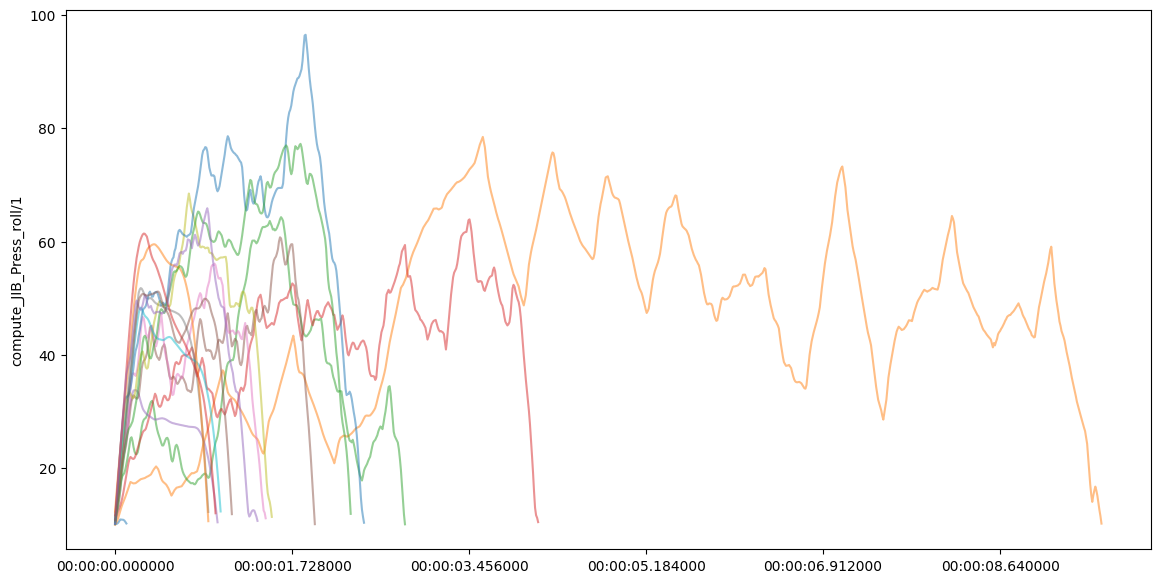

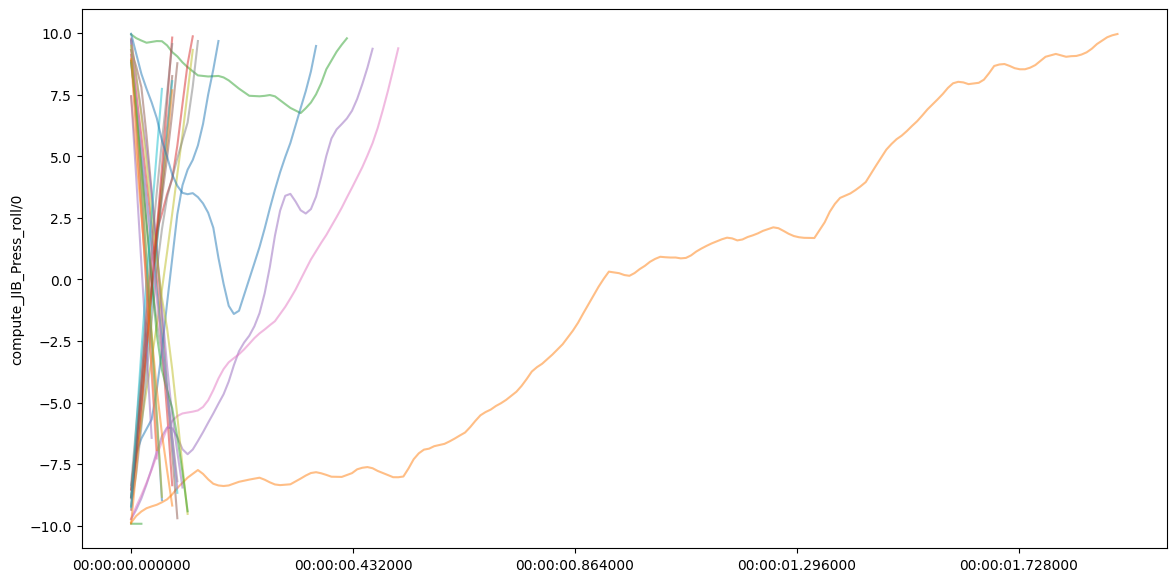

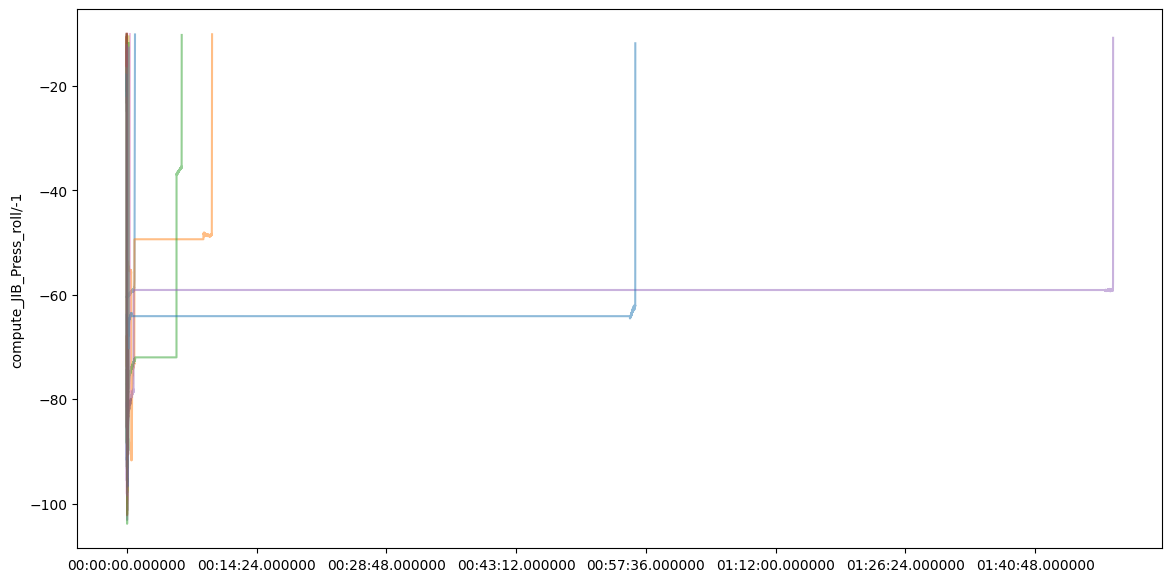

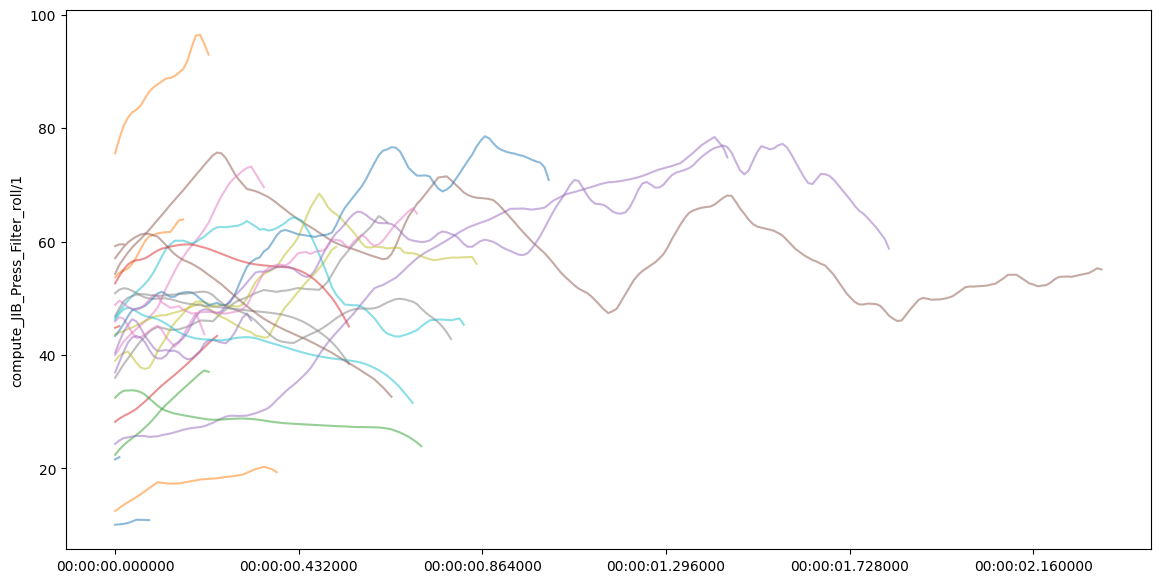

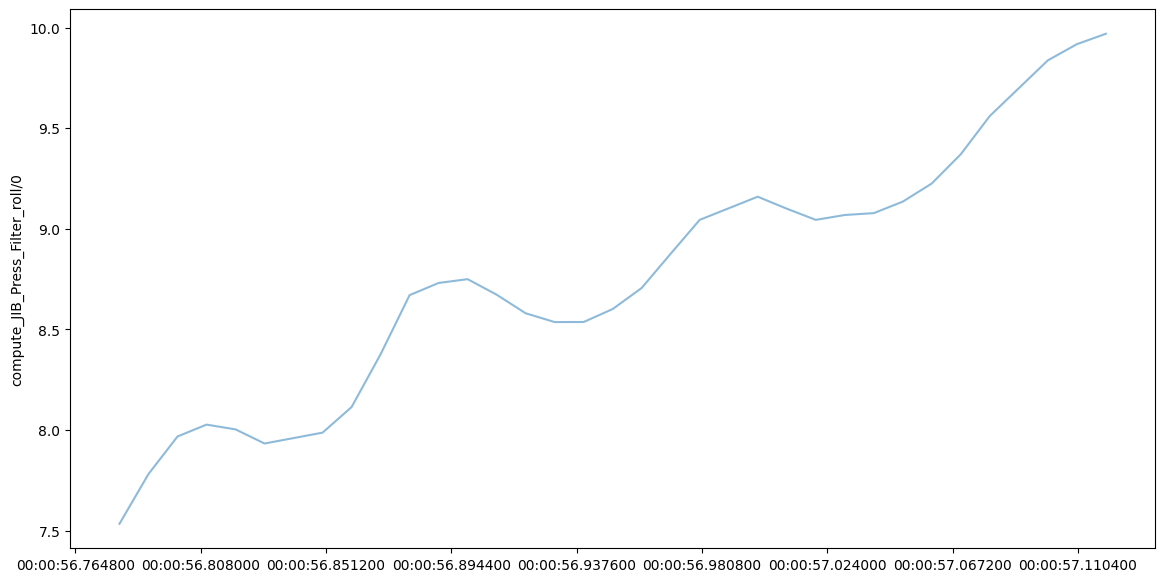

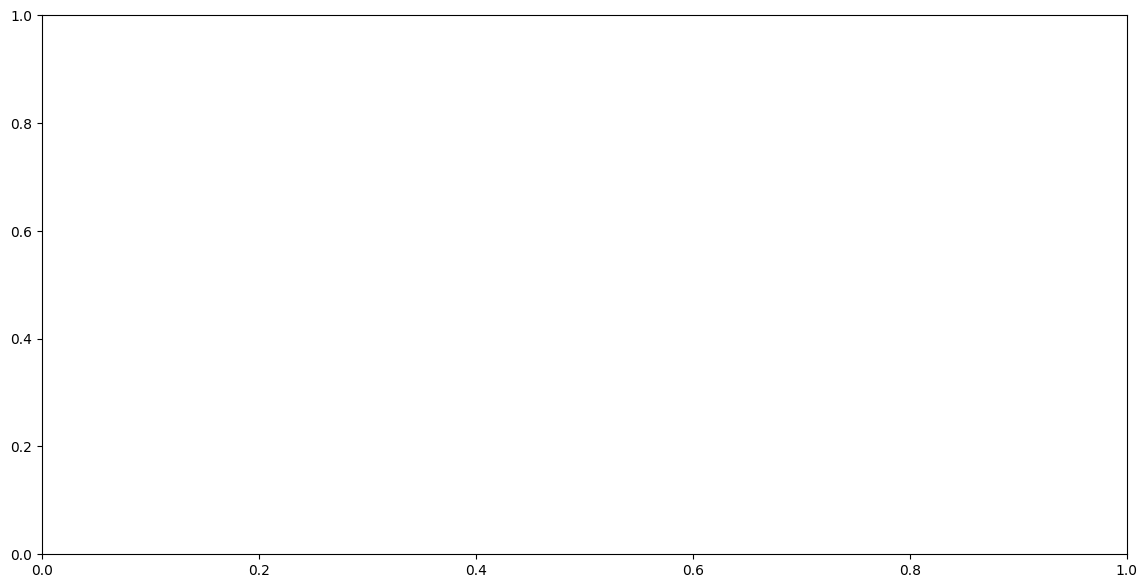

In [96]:
# If needed
df_full = detect(df_full, "compute_JIB_Press_roll", 10, -10)
df_full = detect(df_full, "compute_JIB_Press_Filter_roll", 10, -10)

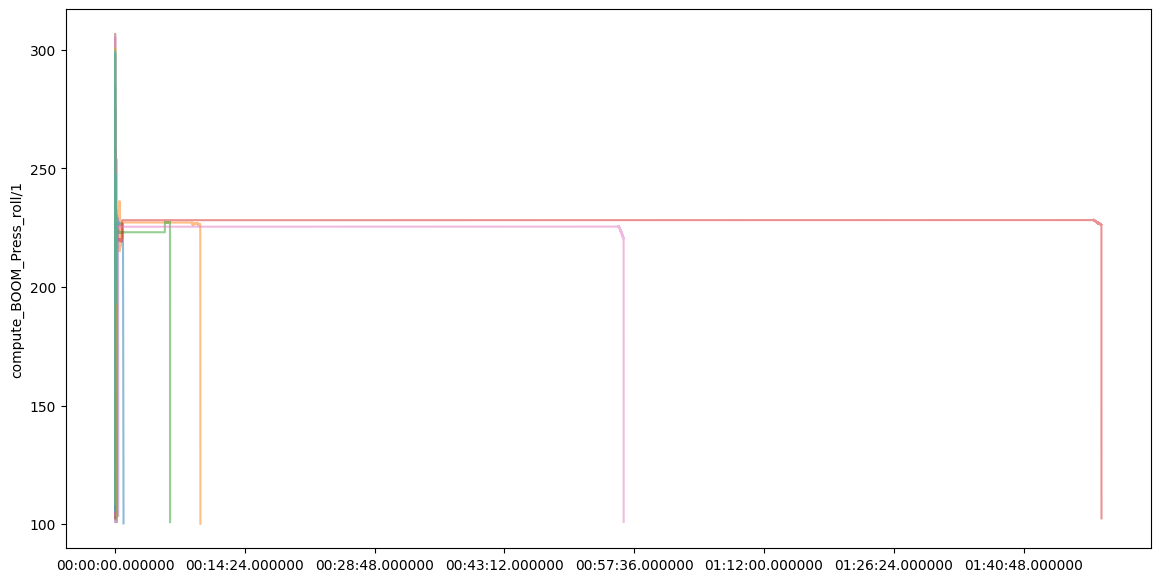

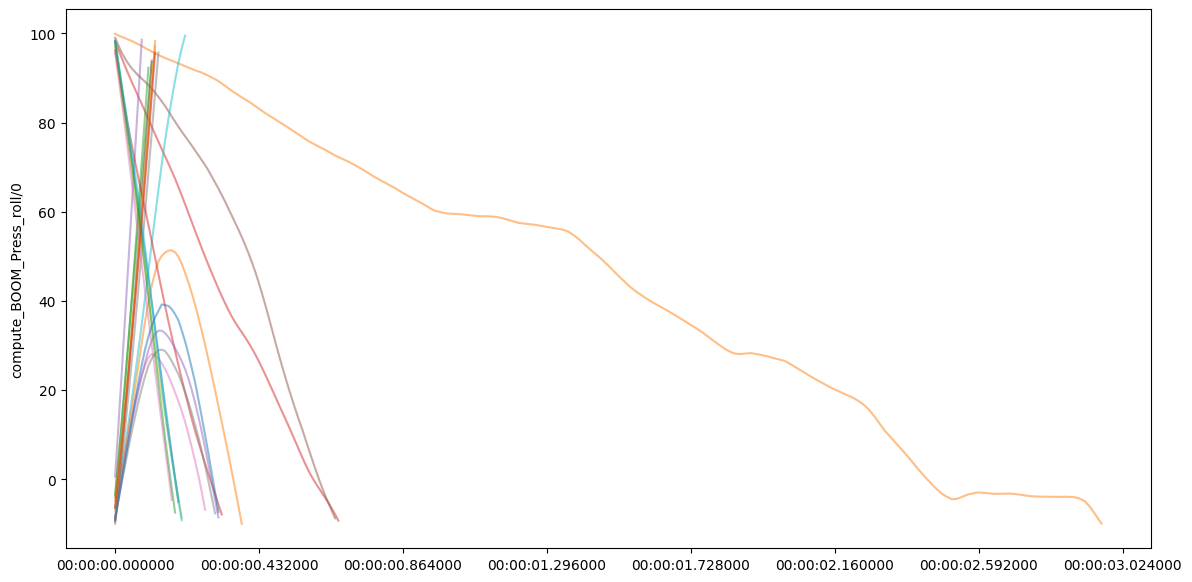

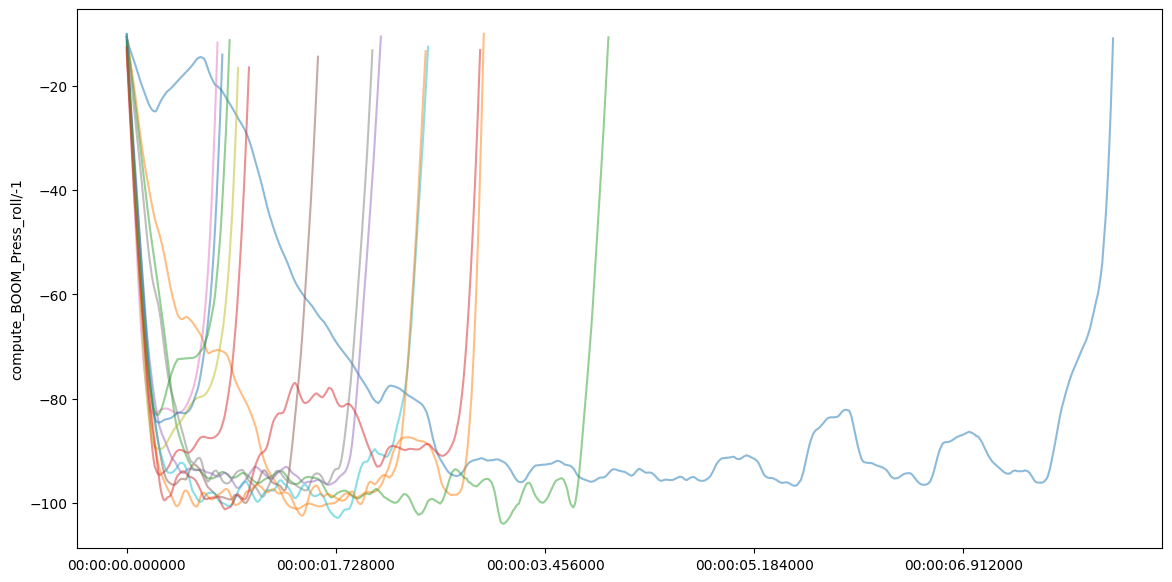

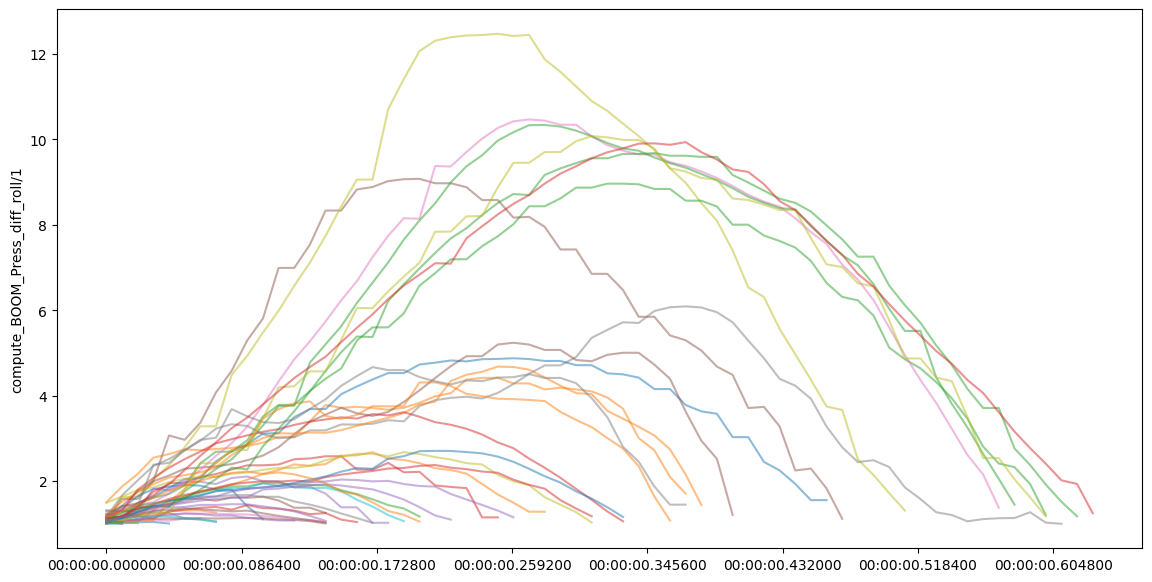

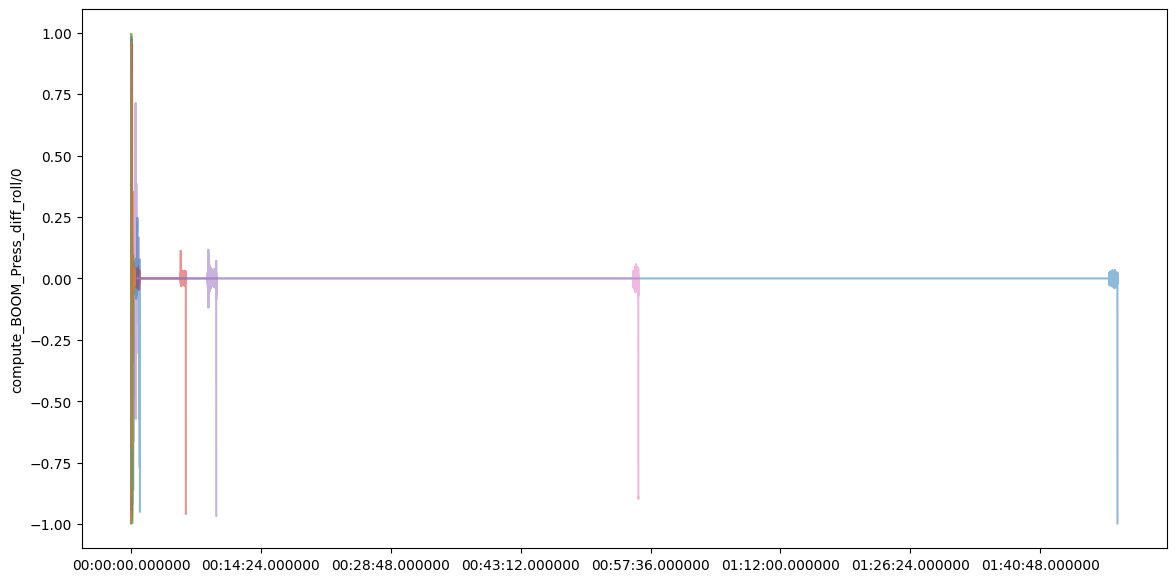

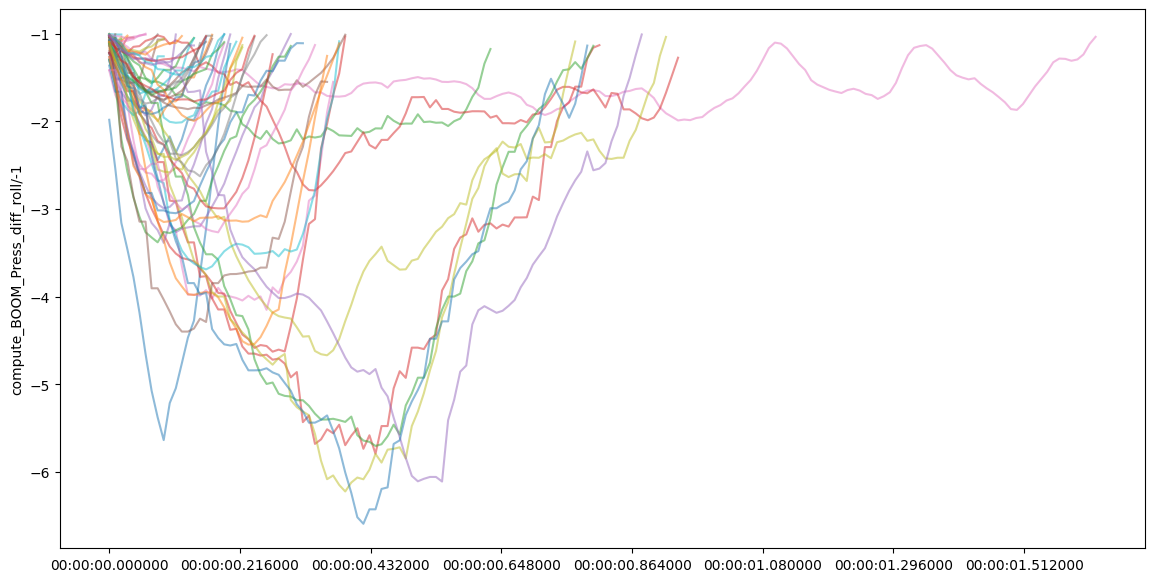

In [97]:
# If needed
df_full = detect(df_full, "compute_BOOM_Press_roll", 100, -10)
df_full = detect(df_full, "compute_BOOM_Press_diff_roll", 1, -1)

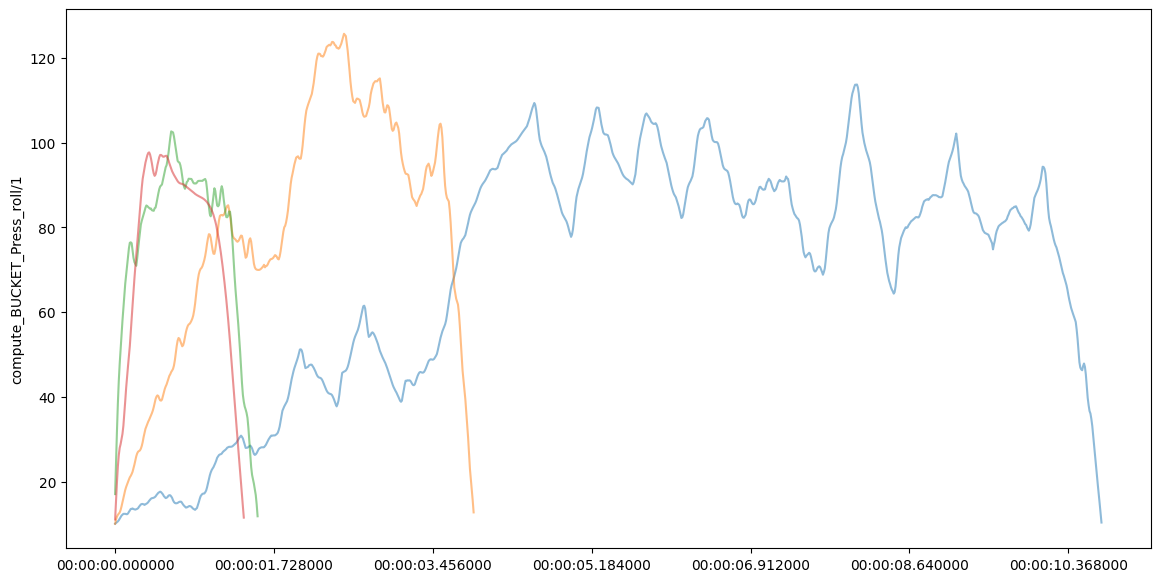

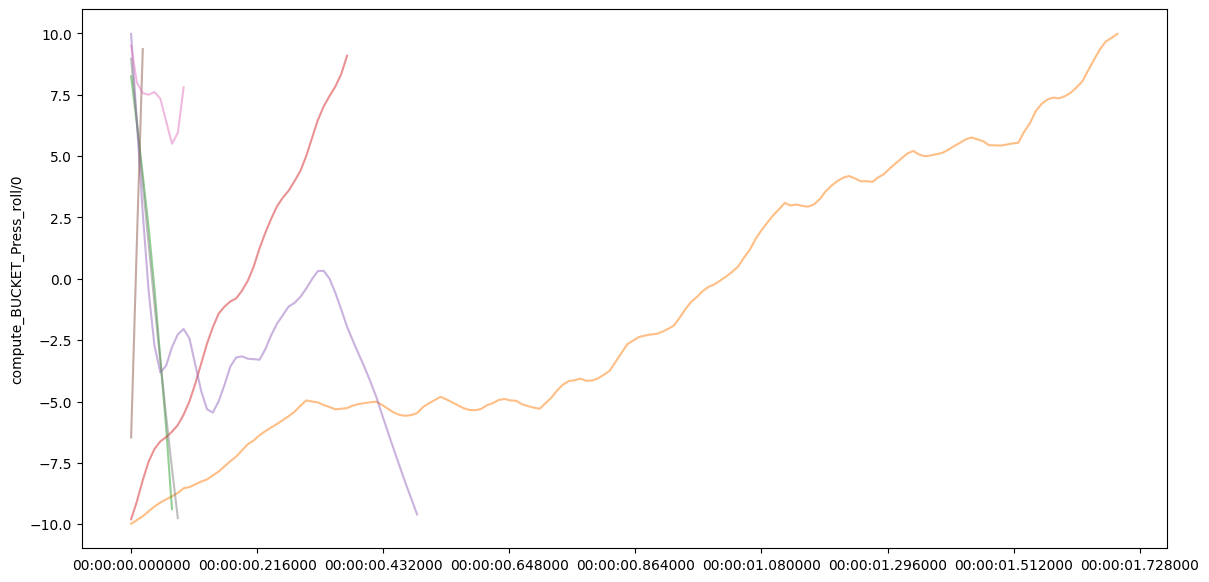

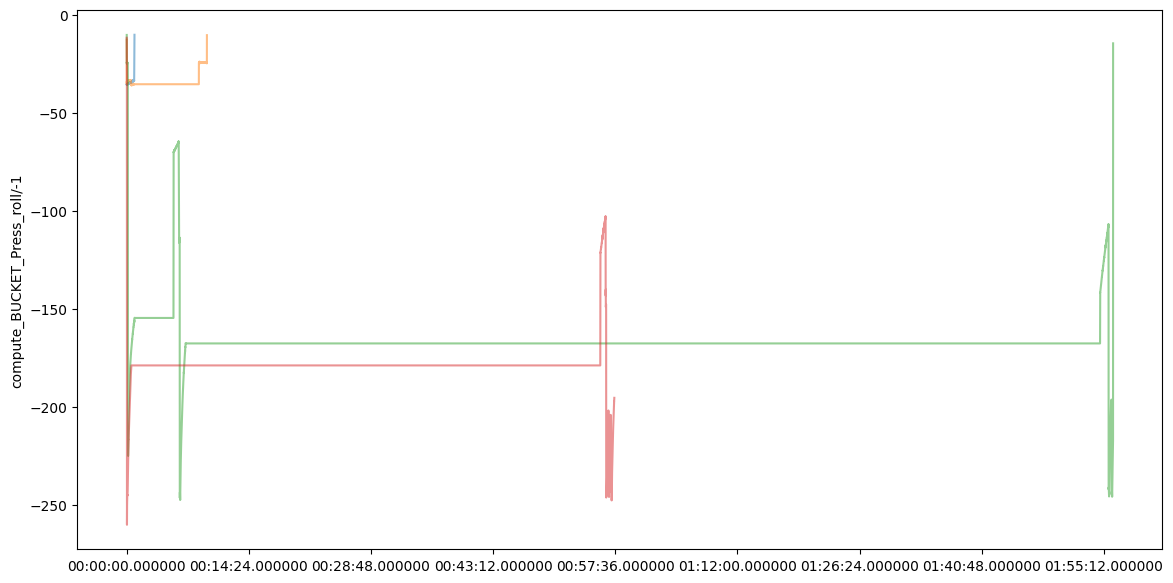

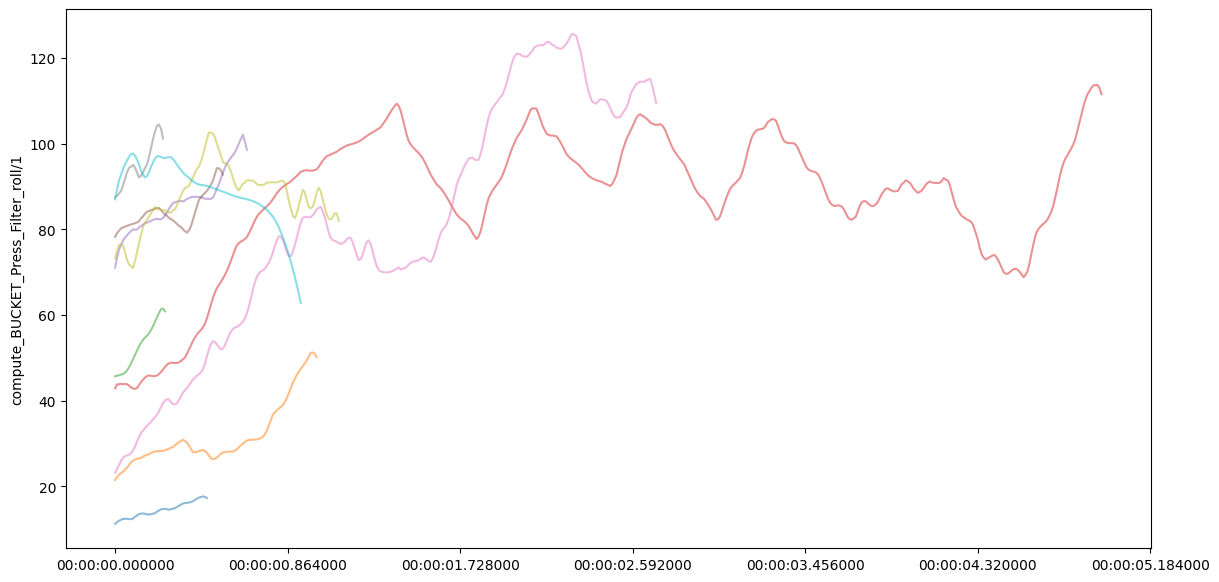

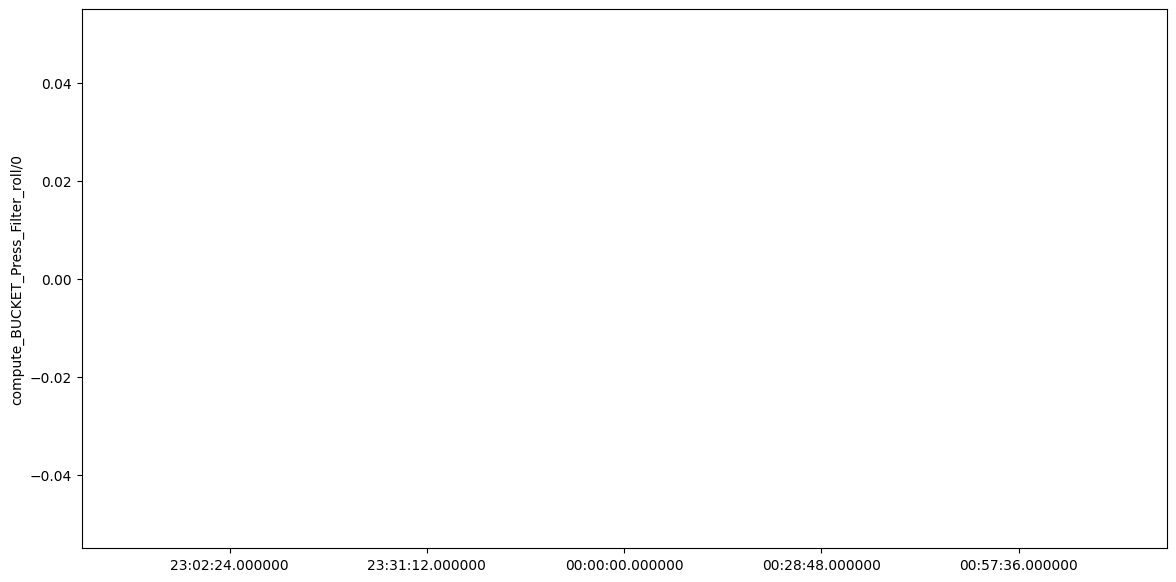

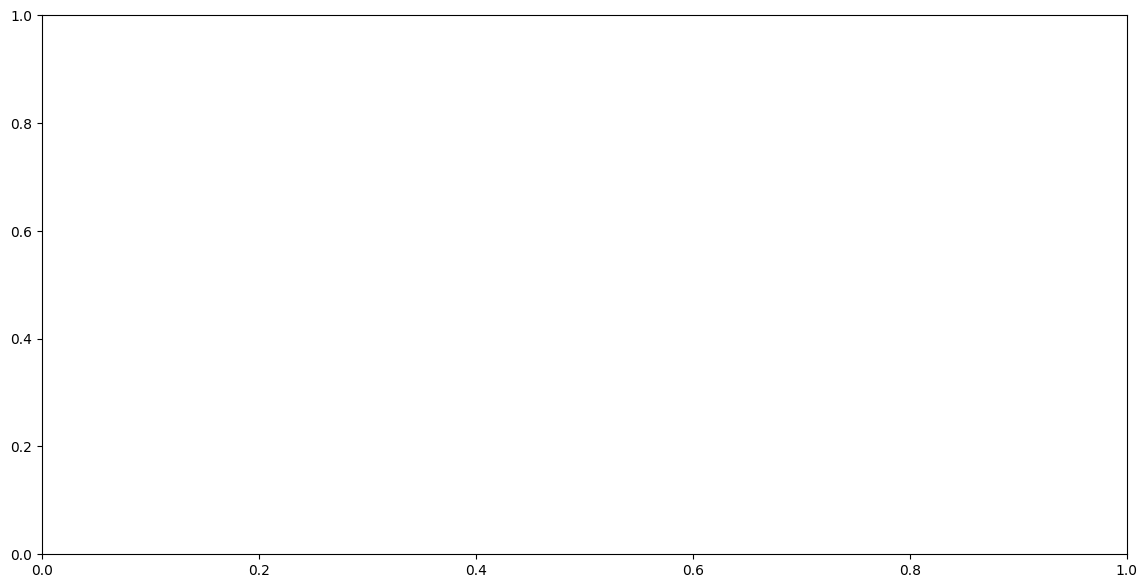

In [98]:
df_full = detect(df_full, "compute_BUCKET_Press_roll", 10, -10)
df_full = detect(df_full, "compute_BUCKET_Press_Filter_roll", 10, -10)

## Détection 1 "Simple"
### Fenêtrage "Simple" sur la pression de BOOM

In [99]:
df_full["compute_inter_state3"] = 0
df_full["compute_inter_state3"] = (
                                   (df_full["compute_BOOM_Press_roll_state"] < 0)
                                  ).astype(int).replace({False: 0, True: 1})

# Create unique index for each group of state : Compute cumulative sum each time "state" change
df_full["compute_inter_state3_cumsum"] = df_full["compute_inter_state3"].ne(df_full["compute_inter_state3"].shift()).cumsum()

# Check if duration is long enought for calcul
gpe3_duration = "compute_final_state3_gpe_duration"
min_time3_s = 0.5
df_full[gpe3_duration] = df_full.groupby(df_full["compute_inter_state3_cumsum"])["ts"].transform(lambda x : (x.iat[-1] - x.iat[0]).total_seconds())
df_full["compute_final_duration_state3"] = 0
df_full["compute_final_duration_state3"][df_full[gpe3_duration] >= min_time3_s] = 1

# df_full["compute_final_duration_state"].plot()

df_full["compute_final_state3"] = ((df_full["compute_inter_state3"] == 1) & (df_full["compute_final_duration_state3"] == 1)).astype(int).replace({False: 0, True: 1})
df_full["compute_final_state3_cumsum"] = df_full["compute_final_state3"].ne(df_full["compute_final_state3"].shift()).cumsum()

C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\785274670.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_full["compute_final_duration_state3"][df_full[gpe3_duration] >= min_time3_s] = 1
C:\Users\g.JANISZEWSKI\AppData\Local

In [100]:
gpe3_mean = "compute_final_state3_gpe_mean"
df3_mean = df_full.groupby([df_full[df_full["compute_final_state3"] == 1]["hardness"], df_full[df_full["compute_final_state3"] == 1]["compute_final_state3_cumsum"]])

In [101]:
gpe_list = [df3_mean]
names_list = ["compute_BOOM_Press_roll", "compute_JIB_Press_roll", "compute_BUCKET_Press_roll"]

name_state_cumsum = "compute_final_state3_cumsum"
hard_colors = ["green", "orange","red"]


In [102]:
SIGNALS_TO_ANALYZE = names_list

## Nouvelle version de plot de signaux

### V3

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from typing import List, Dict, Tuple, Any

# ====================================================================
# A. PARAMÈTRES DE CONFIGURATION GLOBALE
# ====================================================================

# Noms de colonnes configurables
COL_HARDNESS = 'Dureté'
COL_ANG_BUCKET = 'PF_BUCKET_PFAngX'
COL_ID_UNIQUE = 'compute_final_state3_cumsum' #'ID_Unique' 
COL_RADIUS = 'bucket_radius'
COL_BUCKET_RADIUS = COL_RADIUS

COL_VALUE = 'Valeur'
COL_SIGNAL = 'Signal'
COL_ORIGINAL_INDEX = '__ORIGINAL_INDEX__' 

# Critères de filtrage
VALEUR_MIN_PHYSIQUE = -150
IQR_FACTOR = 1.5

# Listes d'analyse
# SIGNALS_TO_ANALYZE = ["compute_BOOM_Press_roll", "compute_JIB_Press_roll", "compute_BUCKET_Press_roll"] #['Signal_1', 'Signal_2', 'Signal_3']
COMPUTATIONS_TO_PLOT = ["min", "max", "mean", "std"]

# HARDNESSES = ['Doux', 'Moyen', 'Dur']
HARDNESSES = [16, 25, 30]
hard_colors_map = {h: plt.colormaps['Set1'](i) for i, h in enumerate(HARDNESSES)}

# ====================================================================
# B. FONCTIONS D'AGRÉGATION ET DE NETTOYAGE
# ====================================================================

def get_q1(x: pd.Series) -> float:
    return x.quantile(0.25)

def get_q3(x: pd.Series) -> float:
    return x.quantile(0.75)

def melt_dataframe(df_base: pd.DataFrame, signals_list: List[str]) -> pd.DataFrame:
    """Convertit le DataFrame au format long, en conservant l'index pour la reconstruction."""
    
    df_reset = df_base.reset_index()
    
    id_vars_list = ['TIME_STAMP', COL_ORIGINAL_INDEX, COL_HARDNESS, COL_ID_UNIQUE, COL_RADIUS, COL_ANG_BUCKET]
    
    missing_cols = [col for col in id_vars_list if col not in df_reset.columns]
    if missing_cols:
        raise ValueError(f"Colonnes manquantes avant melt: {missing_cols}")

    return df_reset.melt(
        id_vars=id_vars_list,
        value_vars=signals_list,
        var_name=COL_SIGNAL,
        value_name=COL_VALUE
    )

# ====================================================================
# B. FONCTIONS D'AGRÉGATION ET DE NETTOYAGE (filter_data modifiée)
# ===================================================================z

# --- Fonctions utilitaires (assumées existantes) ---
def get_q1(s: pd.Series) -> Any:
    return s.quantile(0.25)

def get_q3(s: pd.Series) -> Any:
    return s.quantile(0.75)
# --- Constantes (assumées existantes) ---
# COL_HARDNESS, COL_ID_UNIQUE, COL_SIGNAL, COL_VALUE, VALEUR_MIN_PHYSIQUE, IQR_FACTOR
# ---------------------------------------------------

def filter_data(
    df_long: pd.DataFrame, 
    drop_physical_group: bool = True, 
    drop_iqr_group: bool = False
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Applique le double filtrage (Physique et IQR) et retourne le DataFrame long original 
    et le DataFrame long nettoyé, en fonction des paramètres d'exclusion de groupe.
    """
    
    initial_len = len(df_long)
    # Réinitialisation de l'index du DataFrame initial pour garantir des opérations robustes.
    df_long_copy = df_long.reset_index(drop=True) 
    
    GROUP_KEYS = [COL_HARDNESS, COL_ID_UNIQUE, COL_SIGNAL] 
    SESSION_KEYS = [COL_HARDNESS, COL_ID_UNIQUE]           
    
    print(f"--- Début du Filtrage (Lignes initiales: {initial_len}) ---")

    # Initialiser le DataFrame nettoyé avec la copie de l'original
    df_cleaned = df_long_copy.copy()

    # --- 1. FILTRAGE PHYSIQUE ---
    
    physical_outliers_df = df_cleaned[df_cleaned[COL_VALUE] < VALEUR_MIN_PHYSIQUE].copy()
    
    if not physical_outliers_df.empty:
        if drop_physical_group:
            # SCÉNARIO 1A : Retrait du groupe entier (Session)
            print("  [Physique] Retrait du groupe entier (paramètre actif).")
            
            groups_to_exclude_physical = physical_outliers_df[SESSION_KEYS].drop_duplicates().set_index(SESSION_KEYS).index.tolist()
            
            df_cleaned['Session_Key'] = df_cleaned[SESSION_KEYS].apply(lambda x: tuple(x), axis=1)
            
            df_cleaned = df_cleaned[
                ~df_cleaned['Session_Key'].isin(groups_to_exclude_physical)
            ].drop(columns=['Session_Key']).copy()
            
            print(f"  [Physique] Groupes retirés: {len(groups_to_exclude_physical)}")
            
        else:
            # SCÉNARIO 1B : Retrait du point uniquement
            print("  [Physique] Retrait du point uniquement (paramètre inactif).")
            
            df_cleaned = df_cleaned[df_cleaned[COL_VALUE] >= VALEUR_MIN_PHYSIQUE].copy()
        
        # 💡 CORRECTION : Réinitialiser l'index après un retrait de lignes
        df_cleaned.reset_index(drop=True, inplace=True)
            
    # --- 2. FILTRAGE IQR (Appliqué sur le DataFrame déjà filtré) ---
    
    df_to_analyze = df_cleaned.copy()
    
    # 2.1 Calcul des bornes IQR par groupe de session/signal
    iqr_stats = df_to_analyze.groupby(GROUP_KEYS)[COL_VALUE].agg(
        Q1=get_q1, Q3=get_q3
    ).reset_index()

    iqr_stats['IQR'] = iqr_stats['Q3'] - iqr_stats['Q1']
    iqr_stats['LB'] = iqr_stats['Q1'] - IQR_FACTOR * iqr_stats['IQR']
    iqr_stats['UB'] = iqr_stats['Q3'] + IQR_FACTOR * iqr_stats['IQR']

    # Fusion pour associer les bornes à chaque point (on utilise l'index réinitialisé)
    df_merged = pd.merge(df_to_analyze, iqr_stats[GROUP_KEYS + ['LB', 'UB']], 
                         on=GROUP_KEYS, how='left')
    
    # 2.2 Identifier les outliers IQR (les lignes à retirer)
    iqr_outliers_df = df_merged[
        (df_merged[COL_VALUE] < df_merged['LB']) | 
        (df_merged[COL_VALUE] > df_merged['UB'])
    ].copy()
    
    # On retire les colonnes de bornes APRÈS l'identification pour continuer le filtrage sur df_cleaned
    df_merged.drop(columns=['LB', 'UB'], inplace=True)
    
    if not iqr_outliers_df.empty:
        if drop_iqr_group:
            # SCÉNARIO 2A : Retrait du groupe entier (Session)
            print("  [IQR] Retrait du groupe entier (paramètre actif).")
            
            groups_to_exclude_iqr = iqr_outliers_df[SESSION_KEYS].drop_duplicates().set_index(SESSION_KEYS).index.tolist()
            
            # Recréer la clé si elle a été retirée (au cas où SCÉNARIO 1A n'a pas été exécuté)
            if 'Session_Key' not in df_cleaned.columns:
                 df_cleaned['Session_Key'] = df_cleaned[SESSION_KEYS].apply(lambda x: tuple(x), axis=1)

            df_cleaned = df_cleaned[
                ~df_cleaned['Session_Key'].isin(groups_to_exclude_iqr)
            ].drop(columns=['Session_Key']).copy()
            
            print(f"  [IQR] Groupes retirés: {len(groups_to_exclude_iqr)}")
            
        else:
            # SCÉNARIO 2B : Retrait du point uniquement (par défaut)
            print("  [IQR] Retrait du point uniquement (paramètre inactif).")
            
            # Le problème venait d'ici : il faut supprimer les lignes par leur index DANS df_cleaned.
            # On utilise l'index de df_merged (qui est un index numérique continu après reset_index)
            # pour identifier les lignes à retirer du df_cleaned (qui a le même index numérique continu)
            outlier_indices = iqr_outliers_df.index 
            df_cleaned = df_cleaned.drop(outlier_indices).copy()
        
        # 💡 CORRECTION : Réinitialiser l'index après le filtrage IQR (si suppression de lignes a eu lieu)
        df_cleaned.reset_index(drop=True, inplace=True)

    # --- 3. RÉCAPITULATIF ---
    
    final_len = len(df_cleaned)
    print(f"--- Fin du Filtrage ---")
    print(f"Lignes conservées: {final_len} ({((final_len / initial_len) * 100):.2f}%)")
    print(f"Lignes supprimées: {initial_len - final_len}")

    # On retourne le DataFrame original (non modifié) et le DataFrame nettoyé (index réinitialisé)
    return df_long, df_cleaned

# ====================================================================
# C. FONCTIONS DE TRACÉ
# ====================================================================

def plot_series_data(df_original: pd.DataFrame, signals_list: List[str], colors_map: Dict[str, str], title_suffix: str = "", save_dir: str = "plots"):
    """Fig. 1: Trace les séries temporelles du DataFrame wide."""
    
    # Création d'une copie robuste et vérification de l'index
    df_plot_data = df_original.reset_index().copy()
    
    if 'TIME_STAMP' in df_plot_data.columns:
        df_plot_data = df_plot_data.set_index('TIME_STAMP')
        
    # Vérification de la validité de l'index temporel
    is_time_index = isinstance(df_plot_data.index, (pd.DatetimeIndex, pd.TimedeltaIndex))
    if not is_time_index:
        print("Avertissement: L'index n'est pas temporel. Skipping plot.")
        return

    df_plot_data = df_plot_data.dropna(subset=[COL_HARDNESS, COL_ID_UNIQUE], how='any')
    grouped_data = df_plot_data.groupby([COL_HARDNESS, COL_ID_UNIQUE])
    hardnesses = df_plot_data[COL_HARDNESS].unique().tolist()
    hardnesses.sort()
    nb_hard = len(hardnesses)
    
    for name in signals_list:
        fig1, ax = plt.subplots(nb_hard + 1, 1, figsize=(14, 2 * (nb_hard + 1)))
        fig1.suptitle(f"Séries Temporelles du Signal: {name} {title_suffix}", fontsize=14)

        for key, gp in grouped_data:
            hard = key[0] 
            id_hard = hardnesses.index(hard)
            
            try:
                g = gp.copy()
                
                if g[name].dropna().empty:
                    continue 
                
                # --- LOGIQUE CLÉ DE RÉINITIALISATION DE L'AXE X ---
                if isinstance(g.index, pd.TimedeltaIndex):
                    first_index = g.index[0]
                    g.index = g.index - first_index
                elif isinstance(g.index, pd.DatetimeIndex): # 💡 CORRECTION POUR DATETIMEINDEX
                    first_index = g.index[0]
                    g.index = (g.index - first_index) # Convertit en Timedelta (T=0)
                
                # Le calcul des secondes fonctionne maintenant sur le TimedeltaIndex résultant
                x_seconds = g.index.total_seconds()
                x_days = x_seconds / (24 * 60 * 60)
                current_color = colors_map.get(hard, 'gray')

            except Exception as e:
                print(f"Skipping group {key} for signal {name} due to error: {e}")
                continue 
            
            # Tracé individuel par Dureté
            ax[id_hard].set_ylabel(f"{name} ({hard})")
            ax[id_hard].plot(x_days, g[name], alpha=0.5, color=current_color)
            ax[id_hard].set_title(f"Dureté={hard}", fontsize=10)
            ax[id_hard].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))
            
            # Tracé de la combinaison (Toutes Duretés)
            ax[nb_hard].set_ylabel(name)
            ax[nb_hard].plot(x_days, g[name], alpha=0.3, color=current_color, label=f'{hard} - {key[1]}')
            ax[nb_hard].set_title("Toutes Duretés", fontsize=10)
            ax[nb_hard].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))
            
        # if ax[nb_hard].lines:
        #      ax[nb_hard].legend(fontsize='x-small', title=f"{COL_HARDNESS} - {COL_ID_UNIQUE}")
        
        plt.tight_layout()

        # 💡 AJOUT : Enregistrement de la figure
        filename = f"series_data_{title_suffix.lower()}_{name}.png"
        plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight')
        
        plt.show()
        plt.close(fig1) # Fermer la figure
    # plt.show()

def plot_agg_data(df_long_data: pd.DataFrame, signals_list: List[str], computations_list: List[str], colors_map: Dict[str, str], title_suffix: str = "", save_dir: str = "plots"):
    """Fig. 2: Génère une grille de graphiques affichant Min, Max, Mean, Std vs Radius du DataFrame long."""
    
    # Créer une copie pour travailler dessus
    df_temp = df_long_data.copy()
    
    # 💡 AJUSTEMENT CLÉ : Renommer seulement COL_HARDNESS en 'hard'
    # et s'assurer que COL_SIGNAL et COL_ID_UNIQUE utilisent leurs noms d'origine
    df_temp.rename(columns={
        COL_HARDNESS: 'hard' # Renommer pour la boucle interne uniquement
    }, inplace=True)
    
    # Définir les colonnes de regroupement avec les noms utilisés dans df_temp
    GROUPBY_COLS = ['hard', COL_ID_UNIQUE, COL_SIGNAL]
    
    # 1. Calcul des statistiques
    aggregation_dict = {
        COL_VALUE: computations_list, 
        COL_RADIUS: ['mean']
    }

    # Grouper et agréger
    df_grouped = df_temp.groupby(GROUPBY_COLS).agg(
        aggregation_dict
    ) 

    # Aplatir les colonnes multi-niveaux (affecte uniquement les agrégations)
    # Ex: ('Valeur', 'min') devient 'Valeur_min'
    df_grouped.columns = ['_'.join(col).strip() for col in df_grouped.columns]
    
    # Réinitialiser l'index APRÈS l'aplatissement
    df_grouped = df_grouped.reset_index() 
    
    # Renommage uniquement des colonnes agrégées qui ont besoin d'être clarifiées
    df_grouped.rename(columns={
        f'{COL_RADIUS}_mean': 'bucket_radius_mean'
    }, inplace=True)
    
    # 2. Création de la figure 
    fig2, ax2 = plt.subplots(len(computations_list), len(signals_list), figsize=(15, 12))
    fig2.suptitle(f"COMPUTATIONS vs Bucket Radius {title_suffix}", fontsize=16)
    
    if len(computations_list) == 1 or len(signals_list) == 1:
        ax2 = np.atleast_2d(ax2)

    # 3. Boucle de tracé
    for i_comp, compute in enumerate(computations_list):
        computed_col_name = f'{COL_VALUE}_{compute}'
        
        for i_name, name in enumerate(signals_list):
            ax = ax2[i_comp, i_name]
            
            # Utiliser COL_SIGNAL dans le filtre
            # C'est la ligne qui posait problème : elle doit utiliser COL_SIGNAL car reset_index() l'a ramenée.
            df_plot = df_grouped[df_grouped[COL_SIGNAL] == name]
            
            # Utiliser 'hard' dans le regroupement
            for hard_level, g in df_plot.groupby("hard"):
                color = colors_map.get(hard_level, 'gray')
                
                ax.scatter(
                    x=g["bucket_radius_mean"], 
                    y=g[computed_col_name],
                    alpha=0.6, 
                    label=hard_level,
                    color=color
                )
                
            # Configuration de l'axe
            if i_comp == 0:
                ax.set_title(name, fontsize=12)
            if i_name == 0:
                ax.set_ylabel(compute.upper(), fontsize=11)
            
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(fontsize='x-small', title=COL_HARDNESS)
            
            if i_comp == len(computations_list) - 1:
                 ax.set_xlabel(COL_RADIUS, fontsize=11)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # 💡 AJOUT : Enregistrement de la figure
    filename = f"agg_data_{title_suffix.lower()}_{'_'.join(signals_list)}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close(fig2) # Fermer la figure

def plot_agg_data_ang_bucket(df_long_data: pd.DataFrame, signals_list: List[str], computations_list: List[str], colors_map: Dict[str, str], title_suffix: str = "", save_dir: str = "plots"):
    """Fig. 3: Génère une grille de graphiques affichant Min, Max, Mean, Std vs Angle Bucket du DataFrame long."""
    
    # Créer une copie pour travailler dessus
    df_temp = df_long_data.copy()
    
    # 💡 AJUSTEMENT CLÉ : Renommer seulement COL_HARDNESS en 'hard'
    # et s'assurer que COL_SIGNAL et COL_ID_UNIQUE utilisent leurs noms d'origine
    df_temp.rename(columns={
        COL_HARDNESS: 'hard' # Renommer pour la boucle interne uniquement
    }, inplace=True)
    
    # Définir les colonnes de regroupement avec les noms utilisés dans df_temp
    GROUPBY_COLS = ['hard', COL_ID_UNIQUE, COL_SIGNAL]
    
    # 1. Calcul des statistiques
    aggregation_dict = {
        COL_VALUE: computations_list, 
        COL_ANG_BUCKET: ['mean']
    }

    # Grouper et agréger
    df_grouped = df_temp.groupby(GROUPBY_COLS).agg(
        aggregation_dict
    ) 

    # Aplatir les colonnes multi-niveaux (affecte uniquement les agrégations)
    # Ex: ('Valeur', 'min') devient 'Valeur_min'
    df_grouped.columns = ['_'.join(col).strip() for col in df_grouped.columns]
    
    # Réinitialiser l'index APRÈS l'aplatissement
    df_grouped = df_grouped.reset_index() 
    
    # Renommage uniquement des colonnes agrégées qui ont besoin d'être clarifiées
    df_grouped.rename(columns={
        f'{COL_ANG_BUCKET}_mean': 'bucket_angle_mean'
    }, inplace=True)
    
    # 2. Création de la figure 
    fig3, ax3 = plt.subplots(len(computations_list), len(signals_list), figsize=(15, 12))
    fig3.suptitle(f"COMPUTATIONS vs Bucket Angle {title_suffix}", fontsize=16)
    
    if len(computations_list) == 1 or len(signals_list) == 1:
        ax3 = np.atleast_2d(ax3)

    # 3. Boucle de tracé
    for i_comp, compute in enumerate(computations_list):
        computed_col_name = f'{COL_VALUE}_{compute}'
        
        for i_name, name in enumerate(signals_list):
            ax = ax3[i_comp, i_name]
            
            # Utiliser COL_SIGNAL dans le filtre
            # C'est la ligne qui posait problème : elle doit utiliser COL_SIGNAL car reset_index() l'a ramenée.
            df_plot = df_grouped[df_grouped[COL_SIGNAL] == name]
            
            # Utiliser 'hard' dans le regroupement
            for hard_level, g in df_plot.groupby("hard"):
                color = colors_map.get(hard_level, 'gray')
                
                ax.scatter(
                    x=g["bucket_angle_mean"], 
                    y=g[computed_col_name],
                    alpha=0.6, 
                    label=hard_level,
                    color=color
                )
                
            # Configuration de l'axe
            if i_comp == 0:
                ax.set_title(name, fontsize=12)
            if i_name == 0:
                ax.set_ylabel(compute.upper(), fontsize=11)
            
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(fontsize='x-small', title=COL_HARDNESS)
            
            if i_comp == len(computations_list) - 1:
                 ax.set_xlabel(COL_ANG_BUCKET, fontsize=11)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # 💡 AJOUT : Enregistrement de la figure
    filename = f"agg_data_bucket_ang_{title_suffix.lower()}_{'_'.join(signals_list)}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close(fig3) # Fermer la figure


def find_kde_mode_faithful(data: pd.Series) -> float:
    """
    Estime la mode (largeur maximale du violon) de manière fidèle 
    en utilisant les coordonnées KDE calculées par Seaborn, sans utiliser Scipy 
    directement.
    """
    data_clean = data.dropna()
    if data_clean.empty or len(data_clean) < 2:
        return np.nan
        
    # 1. Créer une figure temporaire invisible pour exécuter le calcul KDE de Seaborn
    fig_temp, ax_temp = plt.subplots(figsize=(1, 1))
    
    # 2. Tracer le KDE (ceci force Seaborn à calculer la densité)
    try:
        sns.kdeplot(x=data_clean, ax=ax_temp)
        
        # 3. Récupérer les données de la courbe
        line = ax_temp.lines[0]
        x_coords = line.get_xdata()
        y_densities = line.get_ydata()
        
        # 4. Trouver l'index de la densité maximale
        max_density_index = np.argmax(y_densities)
        mode_estimated = x_coords[max_density_index]
        
    except IndexError:
        # Gérer le cas où kdeplot échoue (par ex. toutes les données sont identiques, rendant le KDE plat)
        mode_estimated = data_clean.median() 
    except Exception:
        # Pour toute autre erreur générique lors du tracé ou de la récupération des données
        mode_estimated = data_clean.median() 

    # 5. Fermer la figure temporaire IMMÉDIATEMENT
    plt.close(fig_temp)
    
    return mode_estimated

def plot_violin_data(df_long_data: pd.DataFrame, signals_list: List[str], title_suffix: str = "", save_dir: str = "plots"):
    """
    Fig. 3: Trace les diagrammes violons des signaux par Dureté et affiche les statistiques clés 
    (Min, Q1, Mode KDE, Médiane, Q3, Max, Moyenne, Écart-type) dans un tableau.
    Ajoute une ligne horizontale pour la Mode KDE dans chaque diagramme violon.
    """
    
    # 1. CALCUL DES STATISTIQUES GLOBALES 
    
    df_stats = df_long_data.groupby([COL_HARDNESS, COL_SIGNAL]).agg(
        Min=(COL_VALUE, 'min'),
        Q1=(COL_VALUE, lambda x: x.quantile(0.25)),
        Mode_KDE=(COL_VALUE, find_kde_mode_faithful), 
        Médiane=(COL_VALUE, 'median'),
        Q3=(COL_VALUE, lambda x: x.quantile(0.75)),
        Max=(COL_VALUE, 'max'),
        Moyenne=(COL_VALUE, 'mean'),
        Ecart_type=(COL_VALUE, 'std')
    ).reset_index()

    # 2. PRÉPARATION DE LA FIGURE ET DES SOUS-GRAPHES
    
    num_signals = len(signals_list)
    fig3, ax3 = plt.subplots(1, num_signals, figsize=(5 * num_signals, 9.5)) 
    
    if num_signals == 1:
        ax3 = np.array([ax3])
        
    fig3.suptitle(f"Diagrammes Violons des Signaux par Dureté {title_suffix}", fontsize=16)

    fig3.subplots_adjust(bottom=0.35, top=0.9) 
    
    # 3. PRÉPARATION DU TABLEAU DE STATISTIQUES (Données)
    
    STAT_COLS = ['Min', 'Q1', 'Mode_KDE', 'Médiane', 'Q3', 'Max', 'Moyenne', 'Ecart_type']
    STAT_COLS_DISPLAY = ['Min', 'Q1', 'Mode KDE', 'Médiane', 'Q3', 'Max', 'Moyenne', 'Écart-type']
    table_data_cells = []
    col_labels = ['Signal', 'Dureté'] + STAT_COLS_DISPLAY

    for name in signals_list:
        signal_stats = df_stats[df_stats[COL_SIGNAL] == name]
        
        for j, hardness in enumerate(HARDNESSES):
            h_stats = signal_stats[signal_stats[COL_HARDNESS] == hardness]
            
            if not h_stats.empty:
                h_stats = h_stats.iloc[0]
                
                row = [name if j == 0 else '', hardness]
                
                for col_name in STAT_COLS:
                    row.append(f"{h_stats[col_name]:.2f}")

                table_data_cells.append(row)

    # 4. BOUCLE DE TRACÉ DES VIOLONS
    
    for i, name in enumerate(signals_list):
        df_plot = df_long_data[df_long_data[COL_SIGNAL] == name]
        
        # 💡 AJUSTEMENT CLÉ : Traitement par Dureté pour ajouter les lignes de mode KDE
        for k, hardness in enumerate(HARDNESSES):
            # Filtrer les données pour le signal et la dureté actuels
            df_subset = df_plot[df_plot[COL_HARDNESS] == hardness]
            
            if not df_subset.empty:
                # Récupérer la mode KDE pour cette combinaison Signal-Dureté
                # Assurez-vous que df_stats contient bien Mode_KDE pour cette ligne
                mode_kde_value = df_stats[
                    (df_stats[COL_HARDNESS] == hardness) & 
                    (df_stats[COL_SIGNAL] == name)
                ]['Mode_KDE'].iloc[0]
                
                # S'assurer que la valeur n'est pas NaN avant de tracer
                if not pd.isna(mode_kde_value):
                    # Tracer la ligne horizontale pour la mode KDE
                    ax3[i].axhline(y=mode_kde_value, 
                                   color=hard_colors_map[hardness], # Utiliser la couleur de la dureté
                                   linestyle='--', 
                                   linewidth=1.5,
                                   alpha=0.7,
                                   label=f'Mode KDE ({hardness})' if k == 0 else "") # Ajouter label une seule fois

        sns.violinplot(
            x=COL_HARDNESS, y=COL_VALUE, hue=COL_HARDNESS, data=df_plot, ax=ax3[i], 
            inner="quartile", palette="Set1", legend=False 
        )

        ax3[i].set_title(name, fontsize=12)
        ax3[i].set_xlabel(COL_HARDNESS, fontsize=11)
        ax3[i].set_ylabel(COL_VALUE, fontsize=11)
        ax3[i].grid(True, linestyle='--', alpha=0.5)
        # ax3[i].legend(loc='upper right', fontsize=8) # Afficher la légende

    # 5. AFFICHAGE DU TABLEAU 
    
    fig = plt.gcf() 
    
    table_ax = fig.add_axes([0.01, 0.03, 0.98, 0.30])
    table_ax.set_axis_off() 

    table = table_ax.table(
        cellText=table_data_cells,
        cellLoc='center',
        loc='center', 
        colLabels=col_labels
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(9.5) 
    table.scale(1, 1.2) 

    for (row, col), cell in table.get_celld().items():
        if row == -1: 
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor("darkgray")
            
        if col < 2 and row >= 0: 
             cell.set_text_props(weight='bold')
             
    # 💡 AJOUT : Enregistrement de la figure
    filename = f"violin_data_{title_suffix.lower()}_{'_'.join(signals_list)}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close(fig3) # Fermer la figure

def plot_bucket_correlation(
    df_long_data: pd.DataFrame, 
    signals_list: List[str], 
    hard_colors_map: Dict[str, Any], 
    aggregation_func: str = 'mean',
    title_suffix: str = "", 
    save_dir: str = "plots"
):
    """
    Trace les signaux agrégés par 'Bucket_Radius' et groupés par 'Dureté'.

    :param df_long_data: DataFrame en format long (doit contenir COL_BUCKET_RADIUS).
    :param signals_list: Liste des noms de signaux à tracer.
    :param hard_colors_map: Dictionnaire de mapping des couleurs pour la dureté.
    :param aggregation_func: Fonction d'agrégation à utiliser ('mean', 'median', etc.).
    :param title_suffix: Suffixe pour le titre de la figure (ex: BRUTES, FILTRÉES).
    :param save_dir: Chemin du répertoire de sauvegarde.
    """
    
    os.makedirs(save_dir, exist_ok=True)
    
    num_signals = len(signals_list)
    fig, ax = plt.subplots(num_signals, 1, figsize=(10, 4 * num_signals), sharex=True)
    
    if num_signals == 1:
        ax = np.array([ax])

    fig.suptitle(f"Corrélation des Signaux vs. {COL_BUCKET_RADIUS} ({aggregation_func.upper()}) {title_suffix}", fontsize=16)

    for i, signal_name in enumerate(signals_list):
        current_ax = ax[i]
        
        # 1. Filtration et Agrégation
        df_signal = df_long_data[df_long_data[COL_SIGNAL] == signal_name]
        
        # Agrégation de la valeur par Bucket et Dureté
        df_agg = df_signal.groupby([COL_BUCKET_RADIUS, COL_HARDNESS])[COL_VALUE].agg(
            aggregation_func
        ).reset_index()

        # 2. Tracé par Dureté
        for hardness in HARDNESSES:
            df_plot = df_agg[df_agg[COL_HARDNESS] == hardness]
            
            # Utilisation de plot pour tracer la ligne entre les centres de bucket
            current_ax.plot(
                df_plot[COL_BUCKET_RADIUS].astype(str), # Convertir en string pour Matplotlib
                df_plot[COL_VALUE],
                label=f'{hardness} ({aggregation_func.capitalize()})',
                color=hard_colors_map[hardness],
                marker='o',
                linestyle='-'
            )

        # 3. Mise en forme du graphique
        current_ax.set_title(signal_name, fontsize=12)
        current_ax.set_ylabel(f'{signal_name} ({aggregation_func.capitalize()})', fontsize=11)
        current_ax.set_xlabel(COL_BUCKET_RADIUS if i == num_signals - 1 else "", fontsize=11) # X-label uniquement sur le dernier
        current_ax.grid(True, linestyle='--', alpha=0.5)
        current_ax.legend(loc='best', fontsize=9)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Enregistrement de la figure
    filename = f"bucket_corr_{aggregation_func.lower()}_{title_suffix.lower()}_{'_'.join(signals_list)}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
# ====================================================================
# D. FONCTION PRINCIPALE (MAIN)
# ====================================================================

def create_sample_data(n_rows: int = 1000) -> pd.DataFrame:
    """Crée un DataFrame de démonstration avec index temporel et colonnes configurables."""
    ID_COUNT = n_rows // 100
    TIME_INDEX = pd.to_timedelta(np.arange(n_rows), unit='ms')

    df_base = pd.DataFrame({
        COL_HARDNESS: np.random.choice(HARDNESSES, n_rows),
        COL_ID_UNIQUE: np.tile(np.arange(ID_COUNT), n_rows // ID_COUNT)[:n_rows],
        COL_RADIUS: np.repeat(np.random.uniform(5, 15, ID_COUNT), n_rows // ID_COUNT)[:n_rows],
        'Signal_1': np.random.normal(50, 5, n_rows),
        'Signal_2': np.random.normal(10, 2, n_rows),
        'Signal_3': np.random.normal(25, 3, n_rows)
    })
    
    df_base[COL_ORIGINAL_INDEX] = df_base.index # Index numérique 0, 1, 2, ...
    df_base['TIME_STAMP'] = TIME_INDEX 
    
    df_base = df_base.set_index('TIME_STAMP') 

    # Ajout d'outliers (pour s'assurer d'un effet visible)
    num_outliers = int(n_rows * 0.05) 
    df_base.loc[df_base.index[0:num_outliers], 'Signal_1'] = 150 
    df_base.loc[df_base.index[num_outliers:num_outliers*2], 'Signal_3'] = -500 

    return df_base

def main():
    """Exécute l'intégralité du workflow."""
    
    # 1. PRÉPARATION DES DONNÉES DE BASE
    df_base = create_sample_data(n_rows=1000) # Assurez-vous d'avoir 1000 lignes
    df_original_long = melt_dataframe(df_base, SIGNALS_TO_ANALYZE) 

    # 2. FILTRAGE
    # Les paramètres par défaut sont exactement ce que vous demandez :
    # drop_physical_group=True (retrait du groupe pour l'outlier physique)
    # drop_iqr_group=False (retrait du point pour l'outlier IQR)
    df_original_long, df_cleaned_long = filter_data(
        df_long, 
        drop_physical_group=True, 
        drop_iqr_group=False
    )
    
    
    # 3. NOUVELLE RECONSTRUCTION DE df_cleaned_wide (avec introduction de NaN pour les points retirés)
    
    # Étape 1 : Créer la version wide des signaux UNIQUEMENT avec les données filtrées.
    df_cleaned_wide_signals = df_cleaned_long.pivot_table(
        index='TIME_STAMP', 
        columns=COL_SIGNAL, 
        values=COL_VALUE, 
        aggfunc='first' 
    ).reset_index()

    # Étape 2 : Isoler les métadonnées de df_base
    df_base_metadata = df_base.reset_index()[[
        'TIME_STAMP', COL_HARDNESS, COL_ID_UNIQUE, COL_RADIUS
    ]].drop_duplicates(subset=['TIME_STAMP'])

    # Étape 3 : Fusionner les métadonnées (complètes) avec les signaux filtrés (avec les trous/NaN)
    df_cleaned_wide = pd.merge(
        df_base_metadata, 
        df_cleaned_wide_signals, 
        on='TIME_STAMP',
        how='left' # Conserver toutes les TIME_STAMP de l'original
    )
    
    # Étape 4 : Finalisation et application de l'index temporel
    df_cleaned_wide = df_cleaned_wide.set_index('TIME_STAMP').drop(columns=[COL_ORIGINAL_INDEX], errors='ignore')
    df_base = df_base.drop(columns=[COL_ORIGINAL_INDEX], errors='ignore')
    
    print(f"\nDataFrame nettoyé au format wide (df_cleaned_wide) créé avec {len(df_cleaned_wide)} lignes (cible: 1000).")
    
    # 4. TRACÉ DES SÉRIES TEMPORELLES (Fig 1)
    
    print("\n--- Figure 1 : Séries Temporelles BRUTES ---")
    plot_series_data(df_base, SIGNALS_TO_ANALYZE, hard_colors_map, title_suffix="BRUTES")
    
    print("\n--- Figure 1 : Séries Temporelles FILTRÉES ---")
    plot_series_data(df_cleaned_wide, SIGNALS_TO_ANALYZE, hard_colors_map, title_suffix="FILTRÉES")

    # 5. TRACÉ DES STATISTIQUES vs. RAYON (Fig 2)
    
    print("\n--- Figure 2 : Statistiques vs. Rayon BRUTES ---")
    plot_agg_data(df_original_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="BRUTES")

    print("\n--- Figure 2 : Statistiques vs. Rayon FILTRÉES ---")
    plot_agg_data(df_cleaned_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="FILTRÉES")


    # 6. TRACÉ DES STATISTIQUES vs. ANGLE BUCKET (Fig 3)
    plot_agg_data_ang_bucket(df_original_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="BRUTES")

# if __name__ == "__main__":
#     main()

### Execute Workflow v3

C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\3991903857.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base.rename(columns={"hardness":"Dureté"}, inplace=True)
C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\3991903857.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_base['org_idx'] = df_base.index
C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\3991903857.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

--- Début du Filtrage (Lignes initiales: 9939) ---
  [Physique] Retrait du point uniquement (paramètre inactif).
  [IQR] Retrait du point uniquement (paramètre inactif).
--- Fin du Filtrage ---
Lignes conservées: 8474 (85.26%)
Lignes supprimées: 1465

DataFrame nettoyé au format wide (df_cleaned_wide) créé avec 3313 lignes.

--- Diagnostic Fig 2 ---
Colonnes dans df_original_long: ['TIME_STAMP', '__ORIGINAL_INDEX__', 'Dureté', 'compute_final_state3_cumsum', 'bucket_radius', 'PF_BUCKET_PFAngX', 'Signal', 'Valeur']
Valeur de COL_SIGNAL: Signal
NaN dans COL_HARDNESS (base): 0
NaN dans COL_HARDNESS (nettoyé): 0

--- Figure 1 : Séries Temporelles BRUTES ---


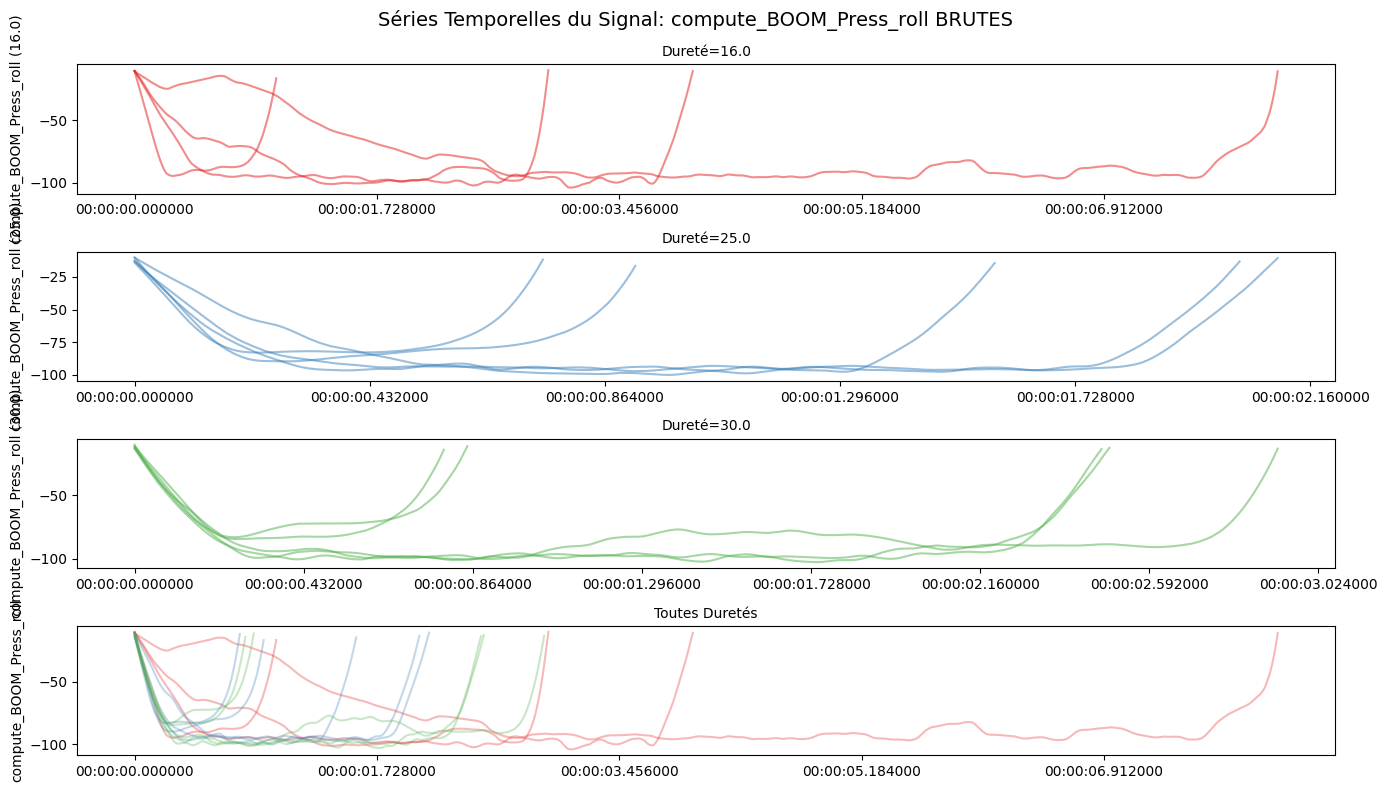

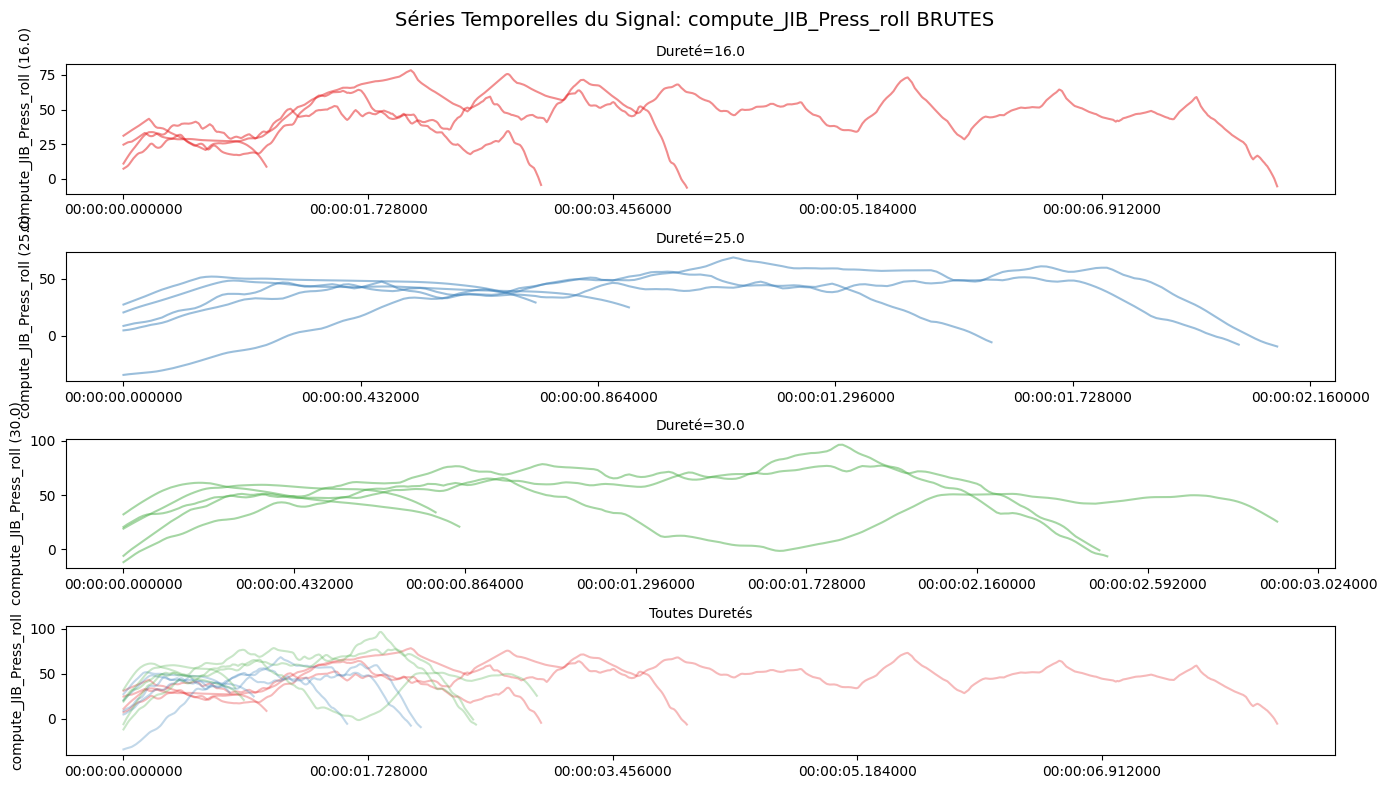

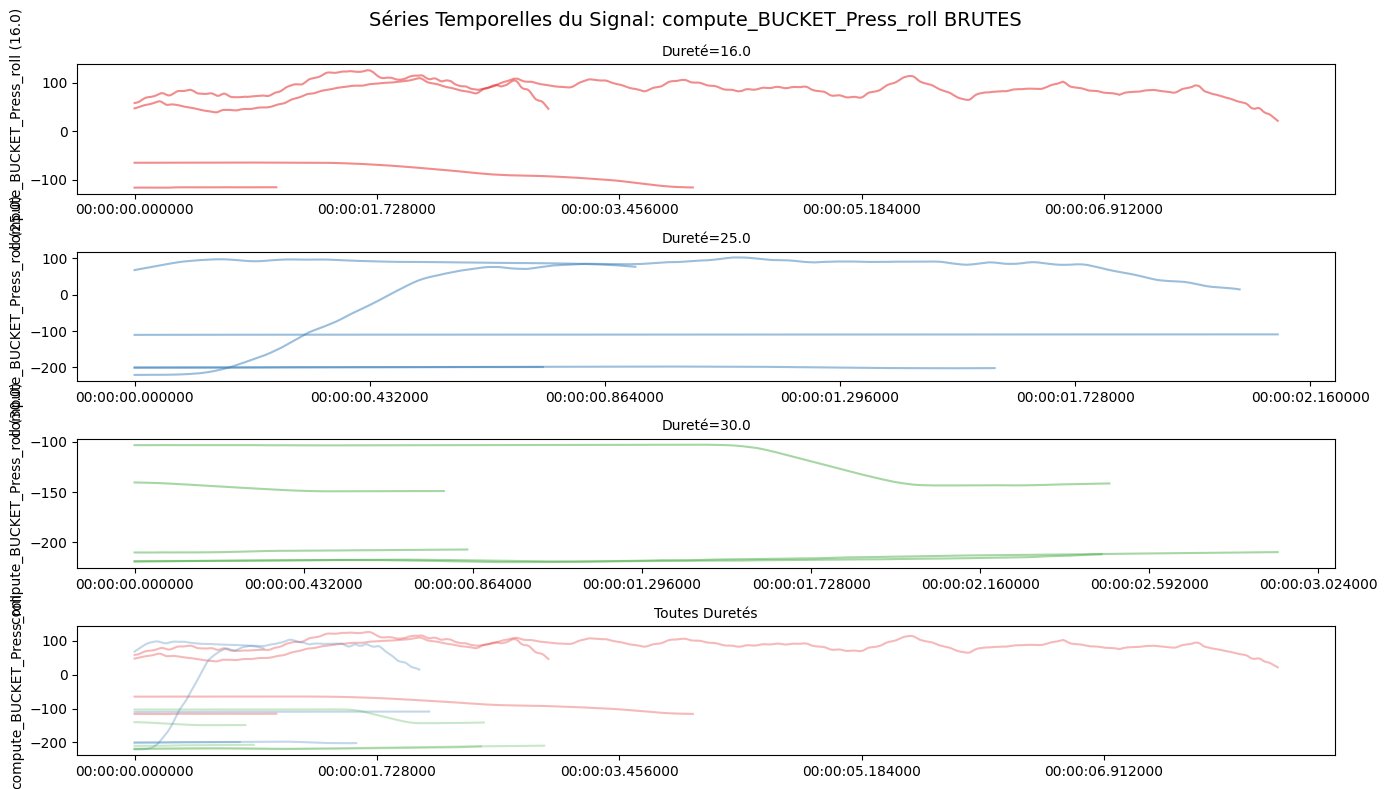


--- Figure 2 : Statistiques vs. Rayon BRUTES ---


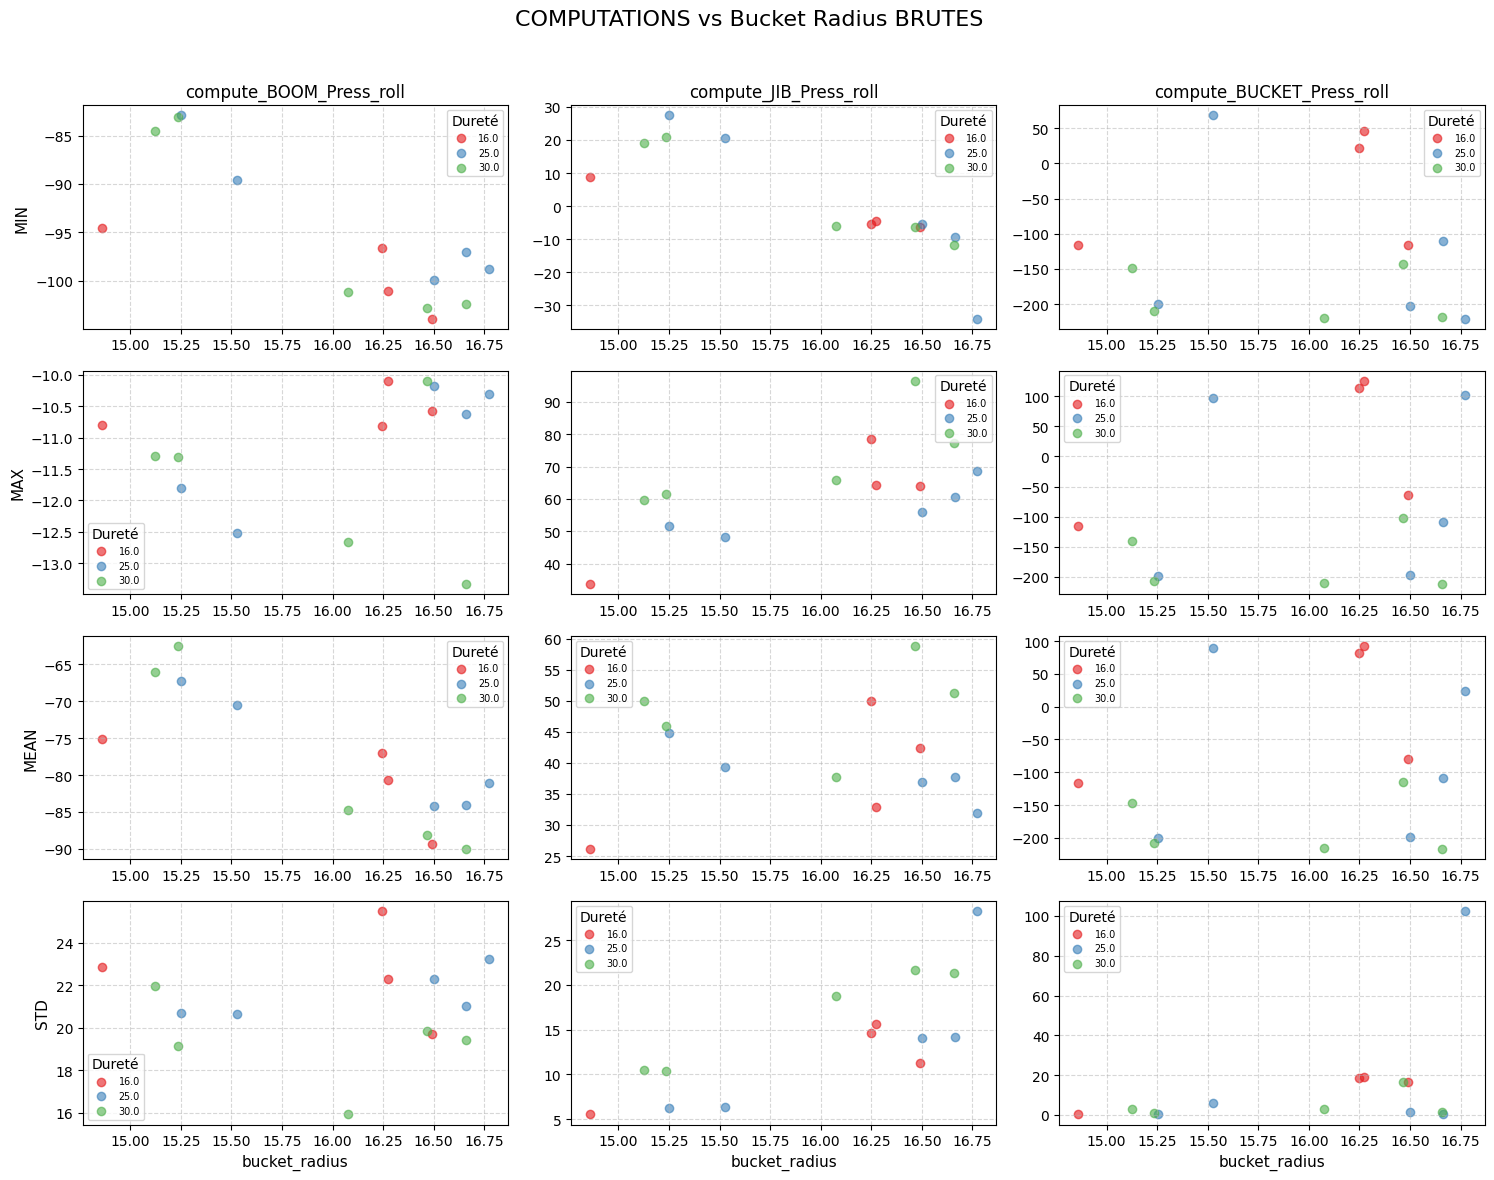


--- Figure 3 : Diagrammes Violons BRUTS avec Stats ---


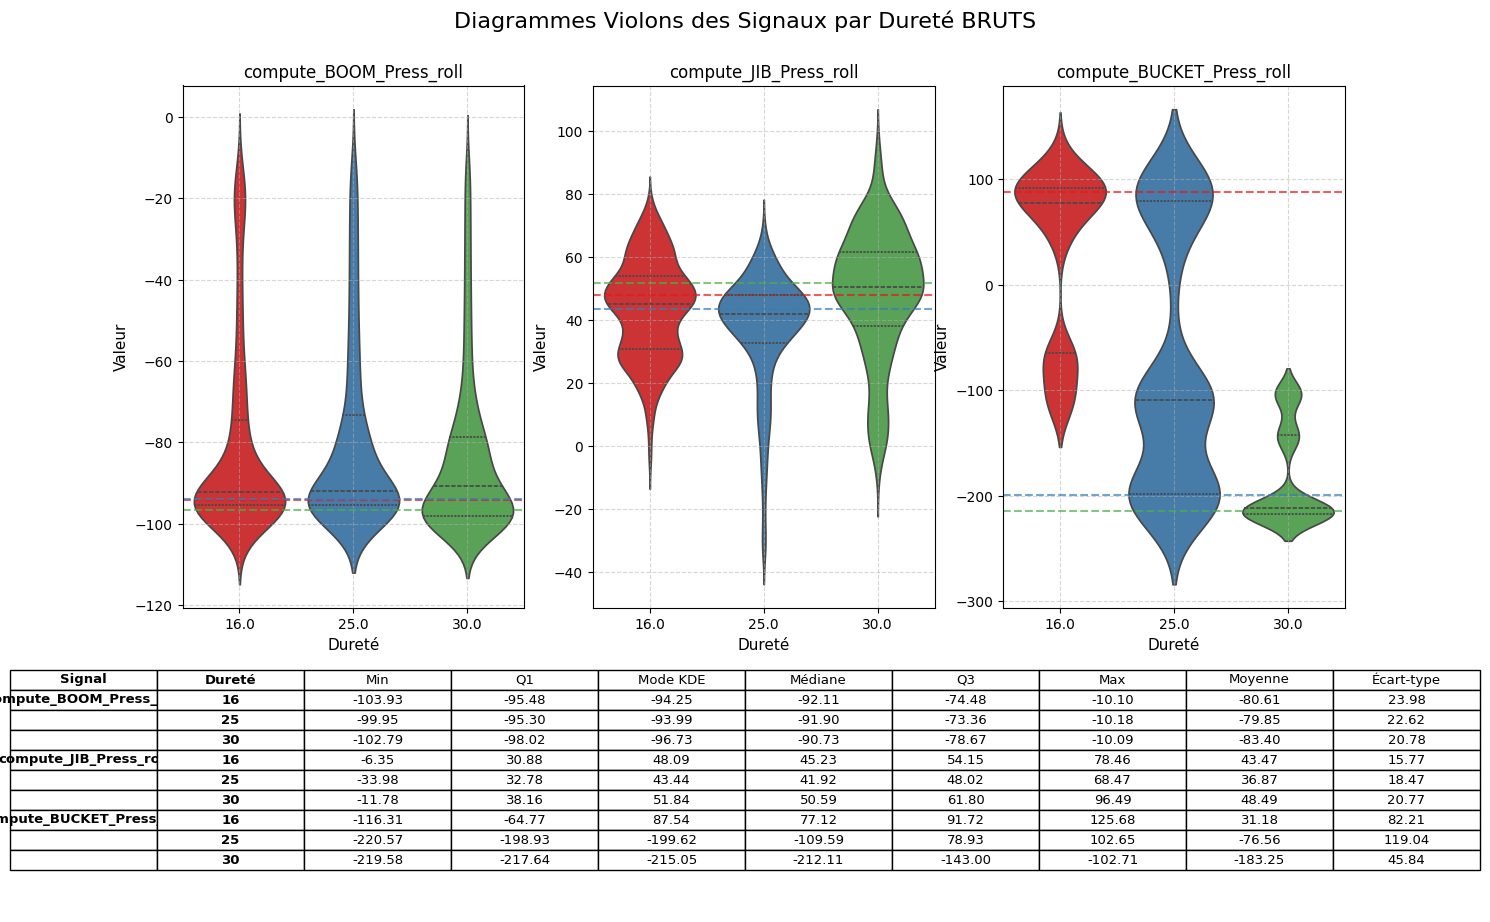


--- Figure 4 : Statistiques vs. Angle Dent BRUTES ---


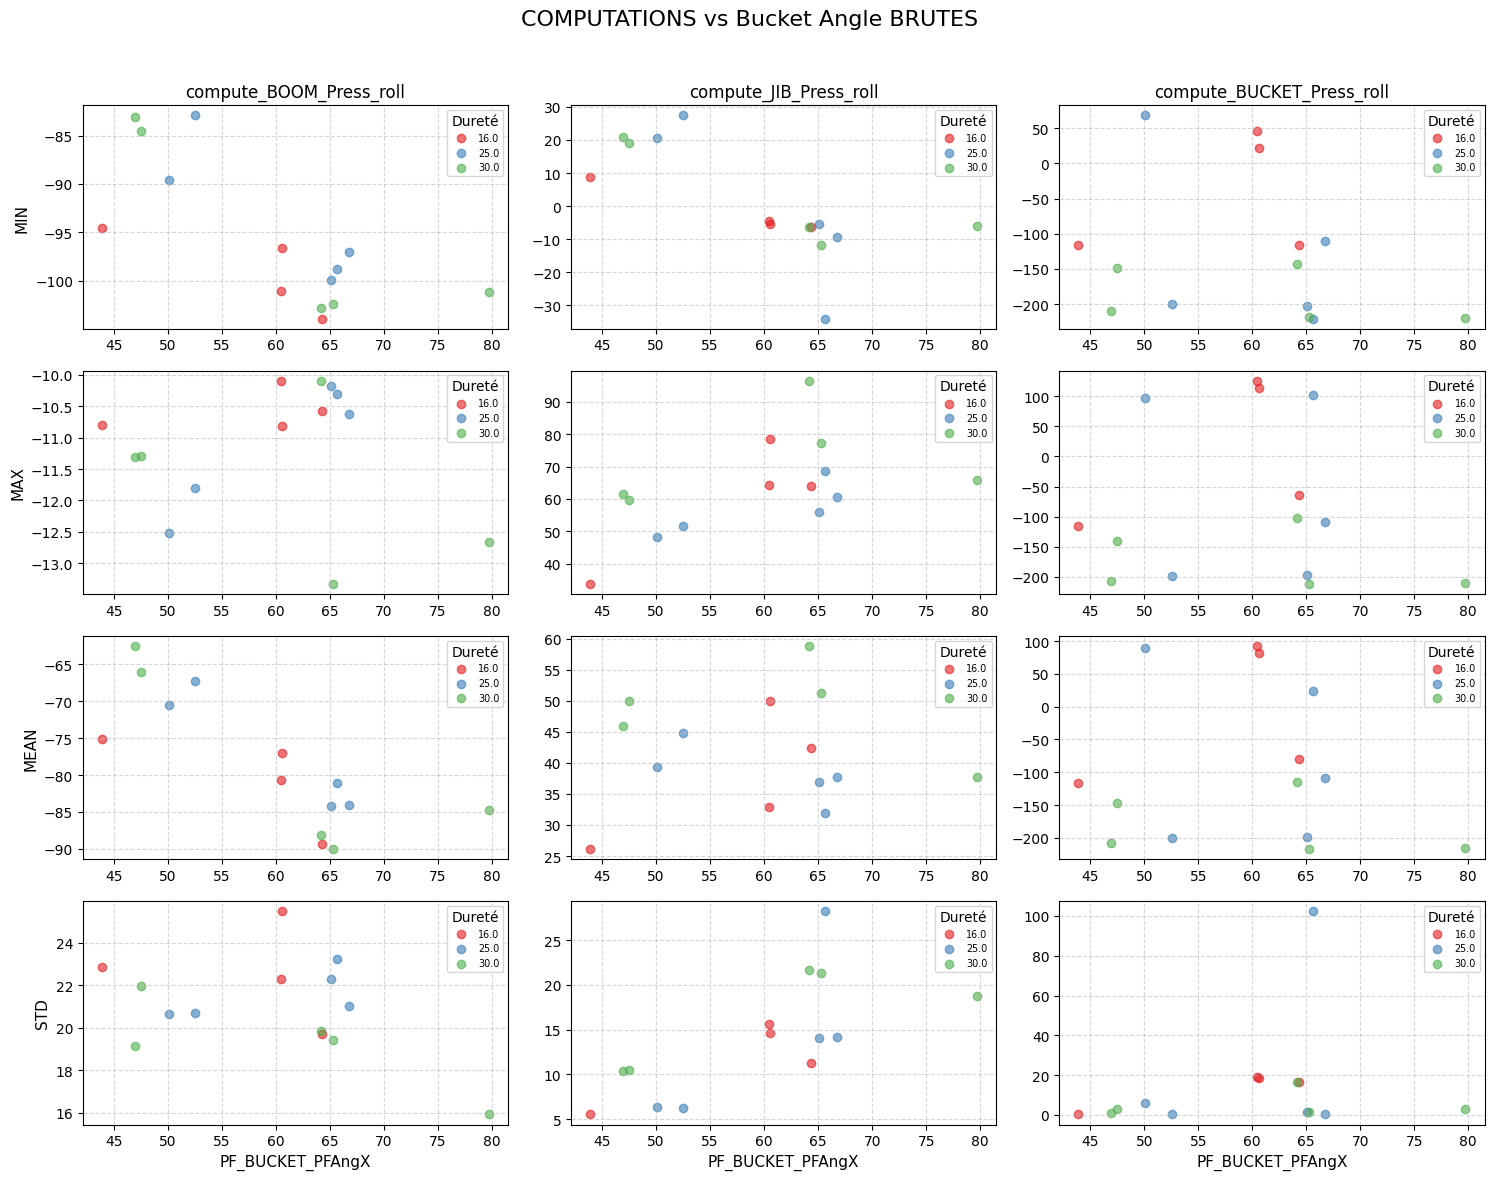

In [ ]:
"""Exécute l'intégralité du workflow. V3"""
"""Exécute l'intégralité du workflow."""

# 1. PRÉPARATION DES DONNÉES DE BASE
# df_base = create_sample_data(n_rows=1000) # Assurez-vous d'avoir 1000 lignes
df_base = df_full[df_full["compute_final_state3"] == 1]
df_base.rename(columns={"hardness":"Dureté"}, inplace=True)
# 💡 AJOUT CLÉ : Créer l'index temporel en tant que colonne avant de l'appliquer
df_base['org_idx'] = df_base.index
df_base.reset_index()
df_base[COL_ORIGINAL_INDEX] = df_base.index
df_base = df_base.set_index('org_idx')
df_base['TIME_STAMP'] = df_base.index

save_directory = "-F1-RAW-output_plots"
os.makedirs(save_directory, exist_ok=True) # Créer le répertoire une seule fois



df_long = melt_dataframe(df_base, SIGNALS_TO_ANALYZE) 

# 2. FILTRAGE
# Les paramètres par défaut sont exactement ce que vous demandez :
# drop_physical_group=True (retrait du groupe pour l'outlier physique)
# drop_iqr_group=False (retrait du point pour l'outlier IQR)
df_original_long, df_cleaned_long = filter_data(
    df_long, 
    drop_physical_group=False, 
    drop_iqr_group=False
)

# 3. NOUVELLE RECONSTRUCTION DE df_cleaned_wide (avec introduction de NaN pour les points retirés)

# Étape 1 : Créer la version wide des signaux UNIQUEMENT avec les données filtrées.
df_cleaned_wide_signals = df_cleaned_long.pivot_table(
    index='TIME_STAMP', 
    columns=COL_SIGNAL, 
    values=COL_VALUE, 
    aggfunc='first' 
).reset_index()

# Étape 2 : Isoler les métadonnées de df_base
df_base_metadata = df_base.reset_index()[[
    'TIME_STAMP', COL_HARDNESS, COL_ID_UNIQUE, COL_RADIUS
]].drop_duplicates(subset=['TIME_STAMP'])

# Étape 3 : Fusionner les métadonnées (complètes) avec les signaux filtrés (avec les trous/NaN)
df_cleaned_wide = pd.merge(
    df_base_metadata, 
    df_cleaned_wide_signals, 
    on='TIME_STAMP',
    how='left' # Conserver toutes les TIME_STAMP de l'original
)

# Étape 4 : Finalisation et application de l'index temporel
df_cleaned_wide = df_cleaned_wide.set_index('TIME_STAMP').drop(columns=[COL_ORIGINAL_INDEX], errors='ignore')
df_base = df_base.drop(columns=[COL_ORIGINAL_INDEX], errors='ignore')

print(f"\nDataFrame nettoyé au format wide (df_cleaned_wide) créé avec {len(df_cleaned_wide)} lignes.")

# --- DIAGNOSTIC CLÉ ICI ---
print("\n--- Diagnostic Fig 2 ---")
print(f"Colonnes dans df_original_long: {df_original_long.columns.tolist()}")
print(f"Valeur de COL_SIGNAL: {COL_SIGNAL}")
# --- FIN DU DIAGNOSTIC ---

# Dans main()
print(f"NaN dans COL_HARDNESS (base): {df_base[COL_HARDNESS].isna().sum()}")
print(f"NaN dans COL_HARDNESS (nettoyé): {df_cleaned_wide[COL_HARDNESS].isna().sum()}")

######### BRUTES ########
# 4. TRACÉ DES SÉRIES TEMPORELLES (Fig 1)
print("\n--- Figure 1 : Séries Temporelles BRUTES ---")
plot_series_data(df_base, SIGNALS_TO_ANALYZE, hard_colors_map, title_suffix="BRUTES", save_dir=save_directory)

# 5. TRACÉ DES STATISTIQUES vs. RAYON (Fig 2)
print("\n--- Figure 2 : Statistiques vs. Rayon BRUTES ---")
plot_agg_data(df_original_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="BRUTES", save_dir=save_directory)

# 6. TRACÉ DES DIAGRAMMES VIOLON (Fig 3) 📊
print("\n--- Figure 3 : Diagrammes Violons BRUTS avec Stats ---")
plot_violin_data(df_original_long, SIGNALS_TO_ANALYZE, title_suffix="BRUTS", save_dir=save_directory)

# 5. TRACÉ DES STATISTIQUES vs. ANGLE DENT (Fig 4)
print("\n--- Figure 4 : Statistiques vs. Angle Dent BRUTES ---")
plot_agg_data_ang_bucket(df_original_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="BRUTES", save_dir=save_directory)


######### FILTREES ########

# print("\n--- Figure 1 : Séries Temporelles FILTRÉES ---")
# plot_series_data(df_cleaned_wide, SIGNALS_TO_ANALYZE, hard_colors_map, title_suffix="FILTRÉES", save_dir=save_directory)

# print("\n--- Figure 2 : Statistiques vs. Rayon FILTRÉES ---")
# plot_agg_data(df_cleaned_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="FILTRÉES", save_dir=save_directory)

# print("\n--- Figure 3 : Diagrammes Violons FILTRÉS avec Stats ---")
# plot_violin_data(df_cleaned_long, SIGNALS_TO_ANALYZE, title_suffix="FILTRÉS", save_dir=save_directory)

# print("\n--- Figure 4 : Statistiques vs. Angle Dent FILTRÉES ---")
# plot_agg_data_ang_bucket(df_cleaned_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="FILTRÉES", save_dir=save_directory)





In [105]:
# displaySig("Detections", df3_mean, ["compute_sumBOOM_JIB_Press_roll", "bucket_radius"], subp="auto")

## Detection 2 : Pressions "Utiles"

In [106]:
df_full["compute_inter_state4"] = 0
df_full["compute_inter_state4"] = ((df_full["compute_BOOM_Press_roll_state"] < 0) #&
                                #    (df_full["compute_JIB_Press_Filter_roll_state"] > 0) &
                                #    (df_full["compute_BUCKET_Press_Filter_roll_state"] > 0)
                                  ).astype(int).replace({False: 0, True: 1})

# Create unique index for each group of state : Compute cumulative sum each time "state" change
df_full["compute_inter_state4_cumsum"] = df_full["compute_inter_state4"].ne(df_full["compute_inter_state4"].shift()).cumsum()

# Check if duration is long enought for calcul
gpe4_duration = "compute_final_state4_gpe_duration"
min_time4_s = 0.5
df_full[gpe3_duration] = df_full.groupby(df_full["compute_inter_state4_cumsum"])["ts"].transform(lambda x : (x.iat[-1] - x.iat[0]).total_seconds())
df_full["compute_final_duration_state4"] = 0
df_full["compute_final_duration_state4"][df_full[gpe3_duration] >= min_time3_s] = 1

# df_full["compute_final_duration_state"].plot()

df_full["compute_final_state4"] = ((df_full["compute_inter_state4"] == 1) & (df_full["compute_final_duration_state4"] == 1)).astype(int).replace({False: 0, True: 1})
df_full["compute_final_state4_cumsum"] = df_full["compute_final_state4"].ne(df_full["compute_final_state4"].shift()).cumsum()

C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\3325178291.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_full["compute_final_duration_state4"][df_full[gpe3_duration] >= min_time3_s] = 1
C:\Users\g.JANISZEWSKI\AppData\Loca

In [107]:
gpe4_mean = "compute_final_state4_gpe_mean"
df4_mean = df_full.groupby([df_full[df_full["compute_final_state4"] == 1]["hardness"], df_full[df_full["compute_final_state4"] == 1]["compute_final_state4_cumsum"]])

In [108]:
gpe_list = [df4_mean]
# names_list = ["compute_BOOM_Press_roll", "compute_JIB_Press_Filter_roll", "compute_BUCKET_Press_Filter_roll"]
names_list = ["compute_BOOM_Press_roll", "compute_JIB_Press_roll_Filter", "compute_BUCKET_Press_roll_Filter"]

name_state_cumsum = "compute_final_state4_cumsum"
hard_colors = ["green", "orange","red"]

### Execution Workflow

In [109]:
SIGNALS_TO_ANALYZE = names_list


C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\2905913140.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base.rename(columns={"hardness":"Dureté"}, inplace=True)
C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\2905913140.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_base['org_idx'] = df_base.index
C:\Users\g.JANISZEWSKI\AppData\Local\Temp\ipykernel_16660\2905913140.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

--- Début du Filtrage (Lignes initiales: 9939) ---
  [IQR] Retrait du point uniquement (paramètre inactif).
--- Fin du Filtrage ---
Lignes conservées: 9381 (94.39%)
Lignes supprimées: 558

DataFrame nettoyé au format wide (df_cleaned_wide) créé avec 3313 lignes.

--- Diagnostic Fig 2 ---
Colonnes dans df_original_long: ['TIME_STAMP', '__ORIGINAL_INDEX__', 'Dureté', 'compute_final_state3_cumsum', 'bucket_radius', 'PF_BUCKET_PFAngX', 'Signal', 'Valeur']
Valeur de COL_SIGNAL: Signal
NaN dans COL_HARDNESS (base): 0
NaN dans COL_HARDNESS (nettoyé): 0

--- Figure 1 : Séries Temporelles FILTRÉES ---


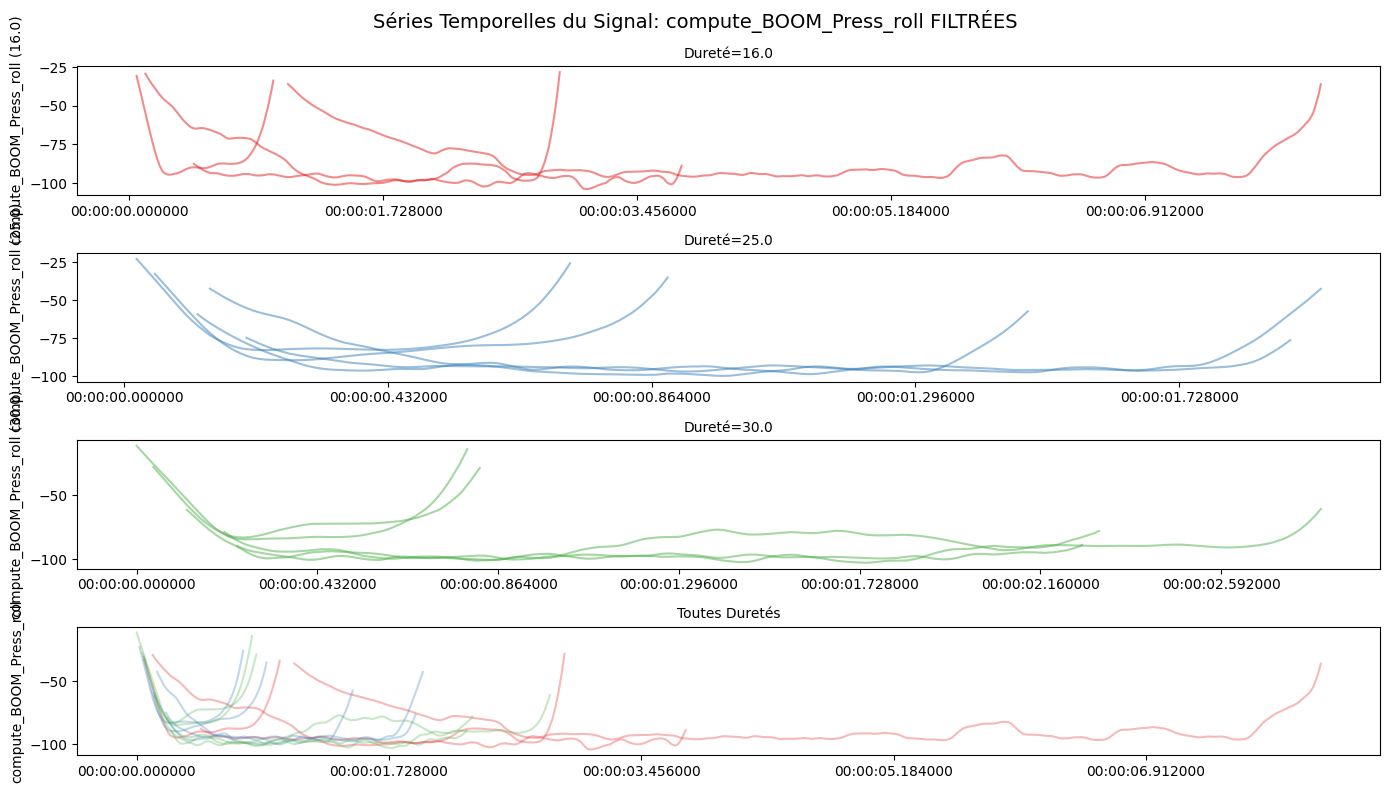

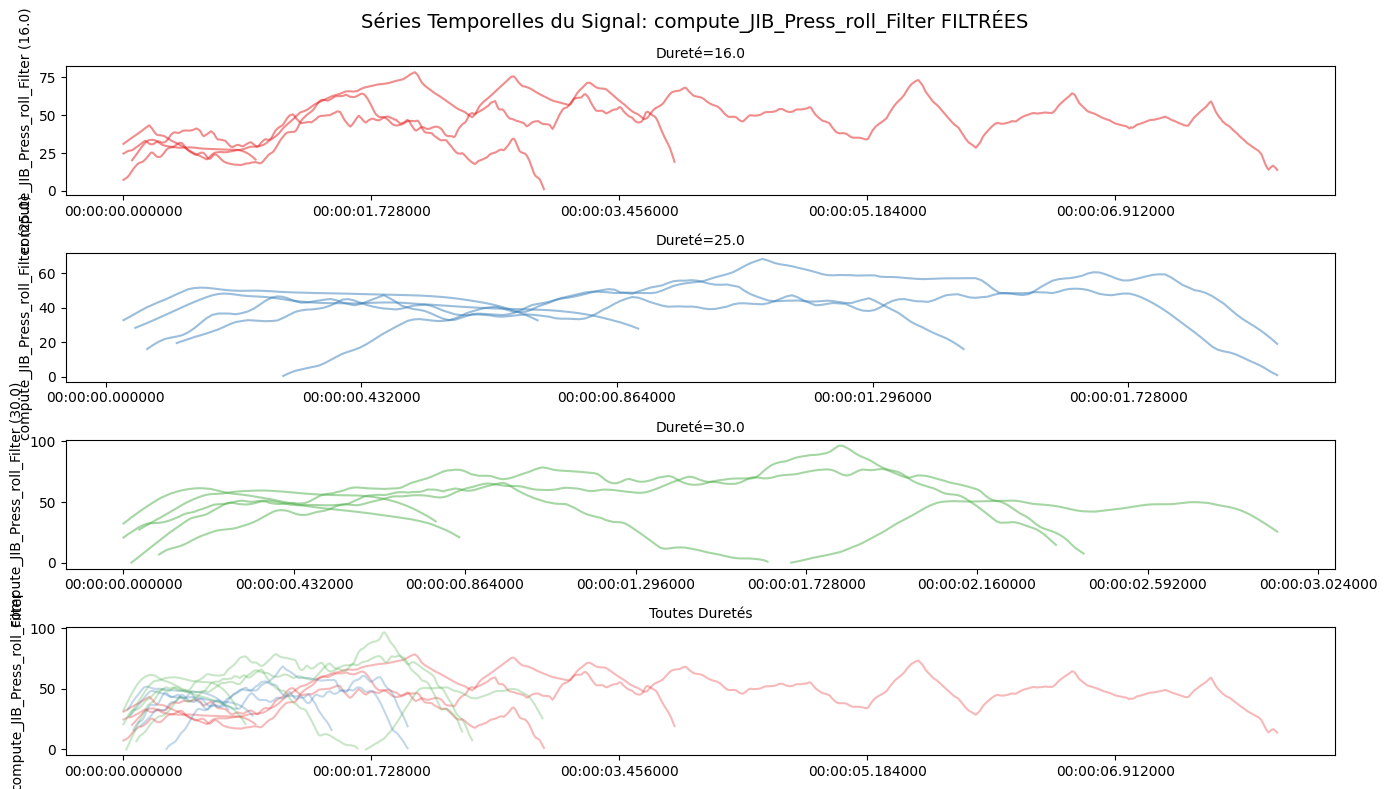

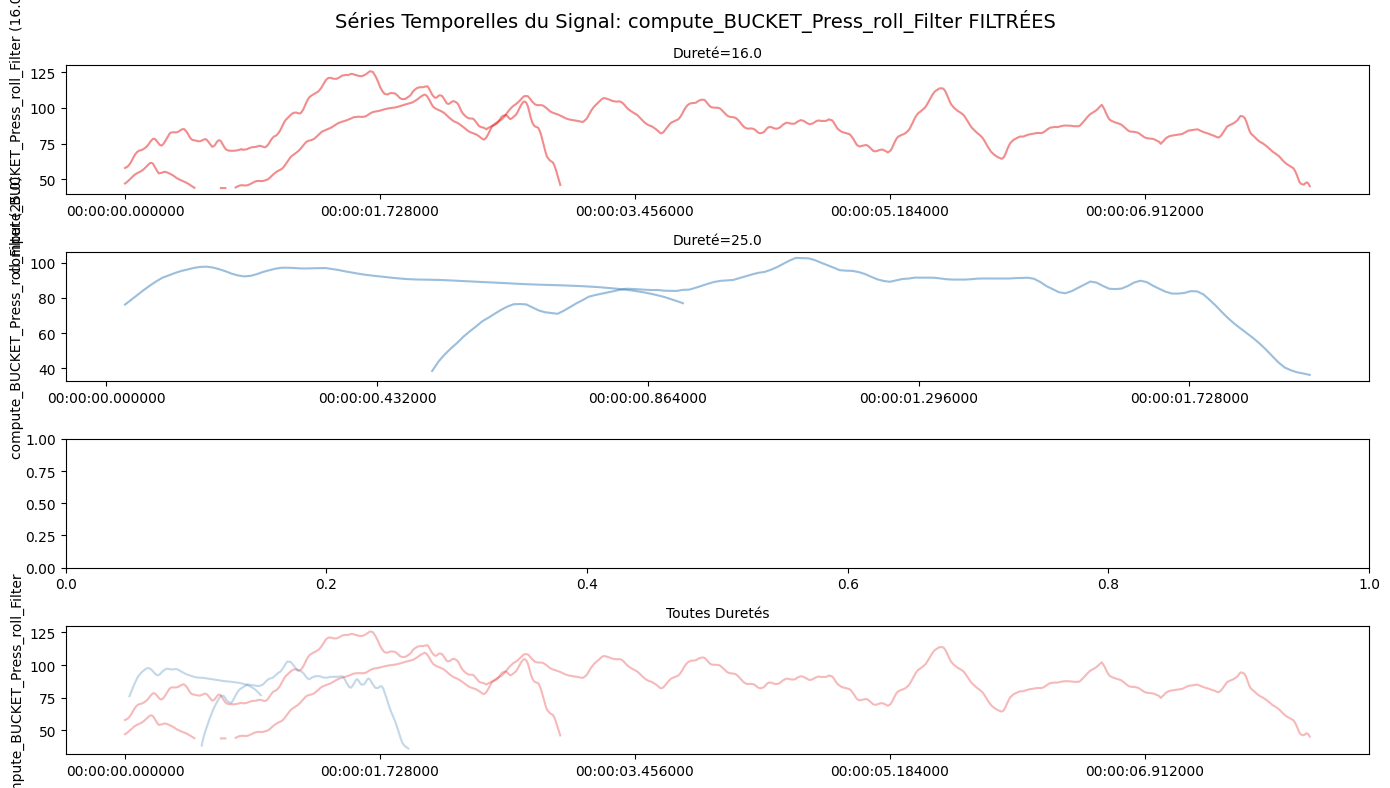


--- Figure 2 : Statistiques vs. Rayon FILTRÉES ---


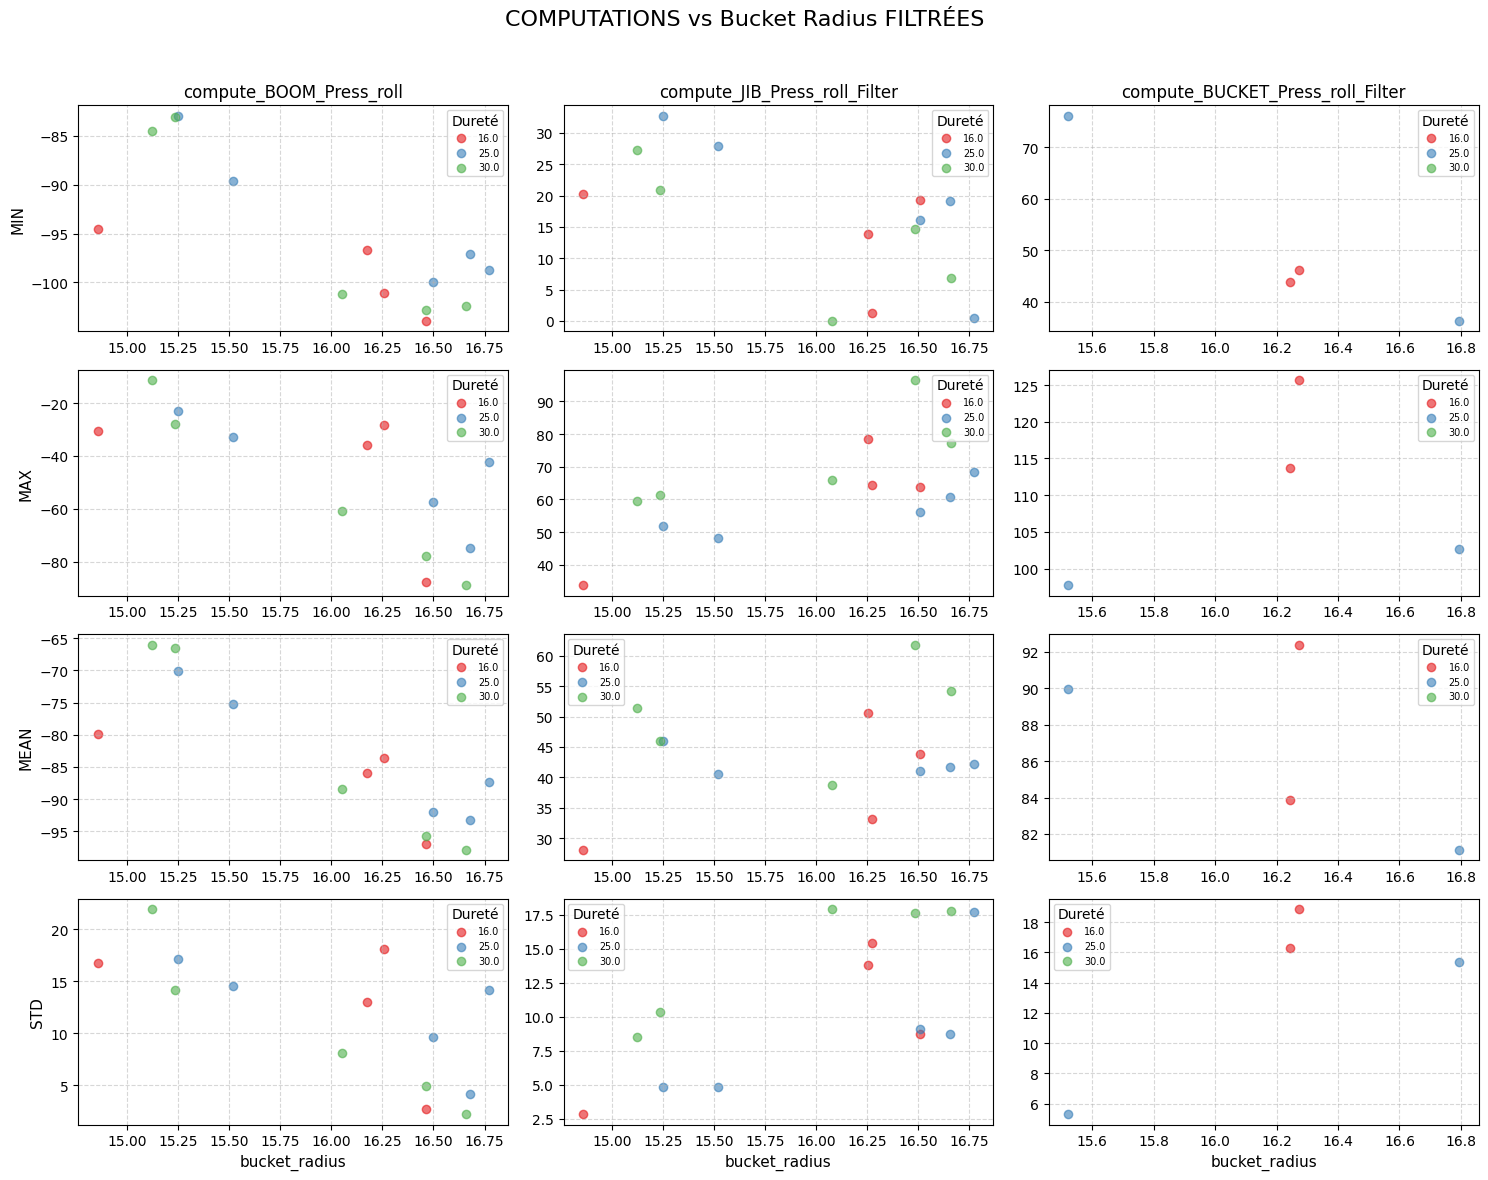


--- Figure 3 : Diagrammes Violons FILTRÉS avec Stats ---


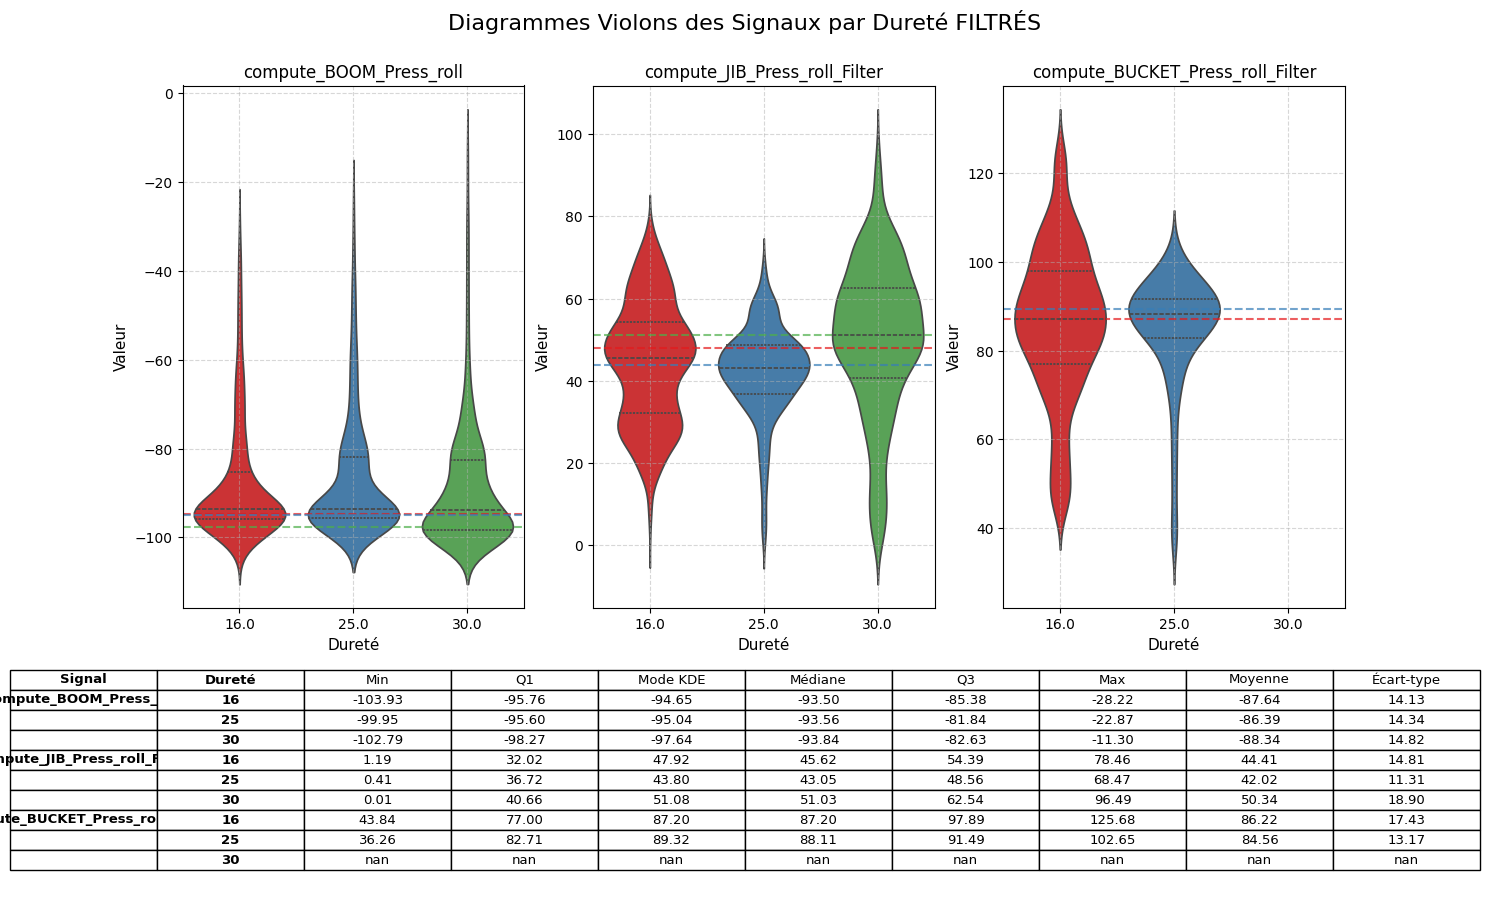


--- Figure 4 : Statistiques vs. Angle Dent FILTRÉES ---


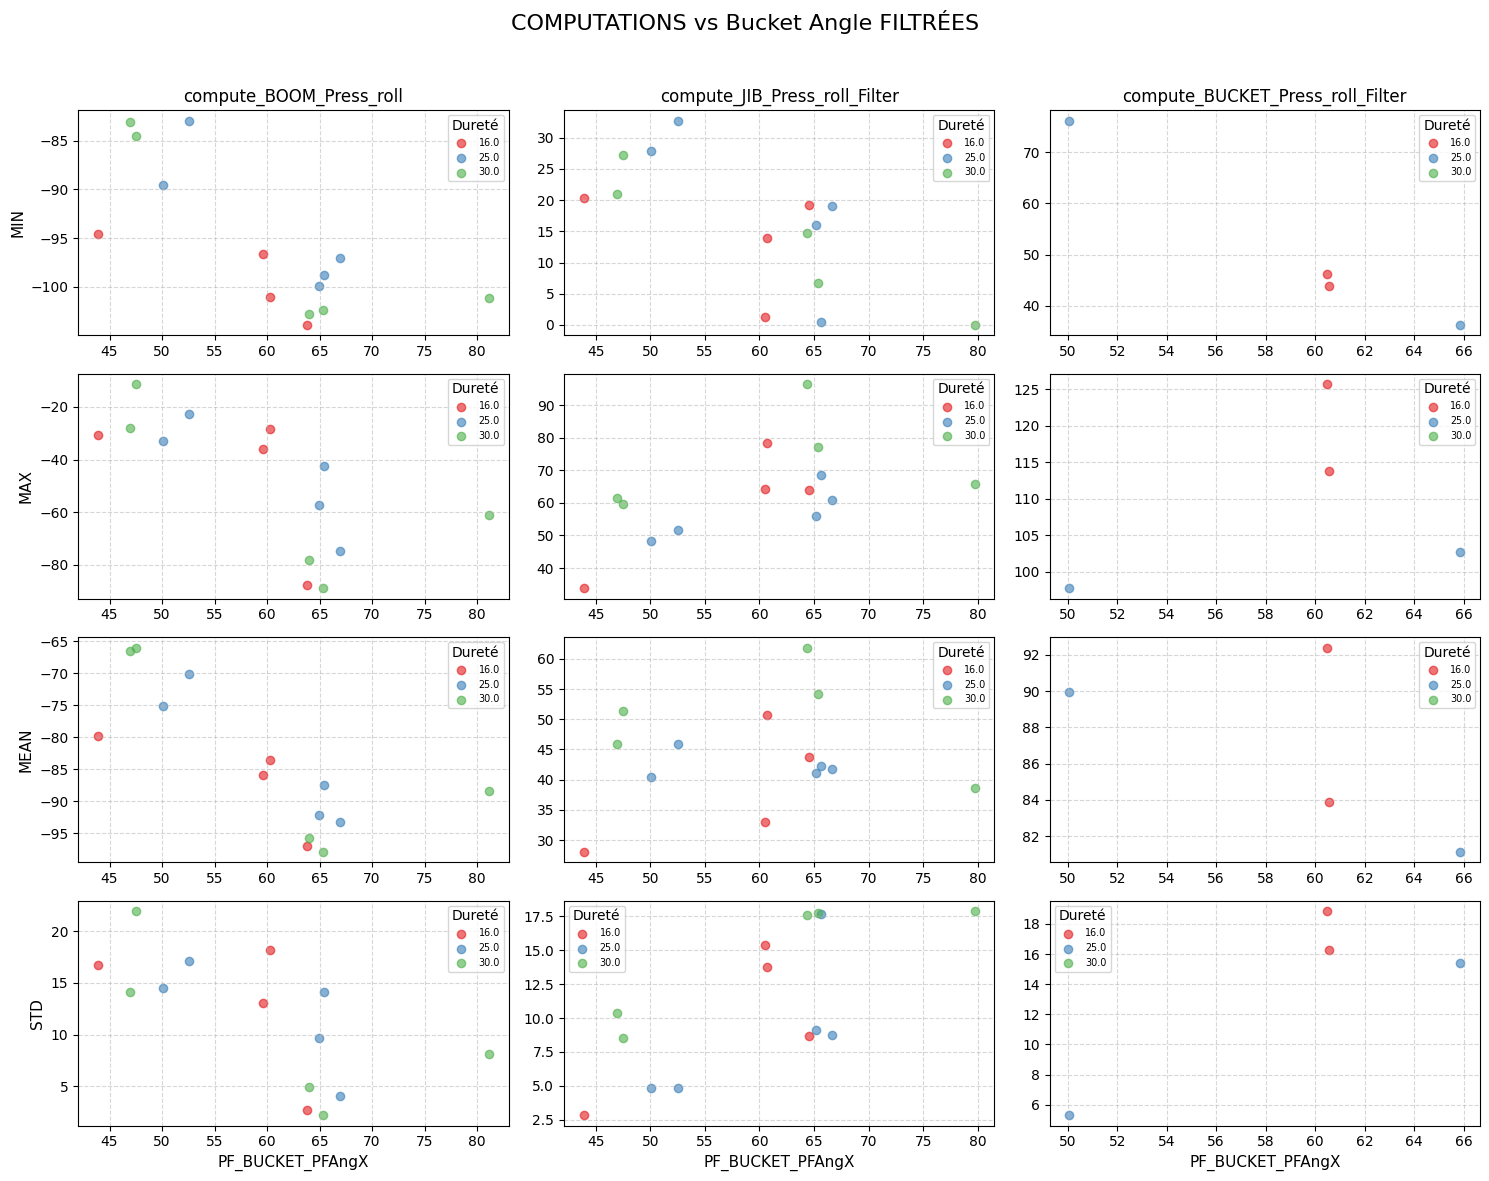

In [ ]:
"""Exécute l'intégralité du workflow. V3"""

# 1. PRÉPARATION DES DONNÉES DE BASE
# df_base = create_sample_data(n_rows=1000) # Assurez-vous d'avoir 1000 lignes
df_base = df_full[df_full["compute_final_state4"] == 1]
df_base.rename(columns={"hardness":"Dureté"}, inplace=True)
# 💡 AJOUT CLÉ : Créer l'index temporel en tant que colonne avant de l'appliquer
df_base['org_idx'] = df_base.index
df_base.reset_index()
df_base[COL_ORIGINAL_INDEX] = df_base.index
df_base = df_base.set_index('org_idx')
df_base['TIME_STAMP'] = df_base.index

save_directory = "-F1-FIL-output_plots"
os.makedirs(save_directory, exist_ok=True) # Créer le répertoire une seule fois



df_long = melt_dataframe(df_base, SIGNALS_TO_ANALYZE) 

# 2. FILTRAGE
# Les paramètres par défaut sont exactement ce que vous demandez :
# drop_physical_group=True (retrait du groupe pour l'outlier physique)
# drop_iqr_group=False (retrait du point pour l'outlier IQR)
df_original_long, df_cleaned_long = filter_data(
    df_long, 
    drop_physical_group=True, 
    drop_iqr_group=False
)
# df_original_long = df_long
# df_cleaned_long = df_long

# 3. NOUVELLE RECONSTRUCTION DE df_cleaned_wide (avec introduction de NaN pour les points retirés)

# Étape 1 : Créer la version wide des signaux UNIQUEMENT avec les données filtrées.
df_cleaned_wide_signals = df_cleaned_long.pivot_table(
    index='TIME_STAMP', 
    columns=COL_SIGNAL, 
    values=COL_VALUE, 
    aggfunc='first' 
).reset_index()

# Étape 2 : Isoler les métadonnées de df_base
df_base_metadata = df_base.reset_index()[[
    'TIME_STAMP', COL_HARDNESS, COL_ID_UNIQUE, COL_RADIUS
]].drop_duplicates(subset=['TIME_STAMP'])

# Étape 3 : Fusionner les métadonnées (complètes) avec les signaux filtrés (avec les trous/NaN)
df_cleaned_wide = pd.merge(
    df_base_metadata, 
    df_cleaned_wide_signals, 
    on='TIME_STAMP',
    how='left' # Conserver toutes les TIME_STAMP de l'original
)

# Étape 4 : Finalisation et application de l'index temporel
df_cleaned_wide = df_cleaned_wide.set_index('TIME_STAMP').drop(columns=[COL_ORIGINAL_INDEX], errors='ignore')
df_base = df_base.drop(columns=[COL_ORIGINAL_INDEX], errors='ignore')

print(f"\nDataFrame nettoyé au format wide (df_cleaned_wide) créé avec {len(df_cleaned_wide)} lignes.")

# --- DIAGNOSTIC CLÉ ICI ---
print("\n--- Diagnostic Fig 2 ---")
print(f"Colonnes dans df_original_long: {df_original_long.columns.tolist()}")
print(f"Valeur de COL_SIGNAL: {COL_SIGNAL}")
# --- FIN DU DIAGNOSTIC ---

# Dans main()
print(f"NaN dans COL_HARDNESS (base): {df_base[COL_HARDNESS].isna().sum()}")
print(f"NaN dans COL_HARDNESS (nettoyé): {df_cleaned_wide[COL_HARDNESS].isna().sum()}")

######### BRUTES ########
# # 4. TRACÉ DES SÉRIES TEMPORELLES (Fig 1)
# print("\n--- Figure 1 : Séries Temporelles BRUTES ---")
# plot_series_data(df_base, SIGNALS_TO_ANALYZE, hard_colors_map, title_suffix="BRUTES", save_dir=save_directory)

# # 5. TRACÉ DES STATISTIQUES vs. RAYON (Fig 2)
# print("\n--- Figure 2 : Statistiques vs. Rayon BRUTES ---")
# plot_agg_data(df_original_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="BRUTES", save_dir=save_directory)

# # 6. TRACÉ DES DIAGRAMMES VIOLON (Fig 3) 📊
# print("\n--- Figure 3 : Diagrammes Violons BRUTS avec Stats ---")
# plot_violin_data(df_original_long, SIGNALS_TO_ANALYZE, title_suffix="BRUTS", save_dir=save_directory)

# # 5. TRACÉ DES STATISTIQUES vs. ANGLE DENT (Fig 4)
# print("\n--- Figure 4 : Statistiques vs. Angle Dent BRUTES ---")
# plot_agg_data_ang_bucket(df_original_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="BRUTES", save_dir=save_directory)


######### FILTREES ########

print("\n--- Figure 1 : Séries Temporelles FILTRÉES ---")
plot_series_data(df_cleaned_wide, SIGNALS_TO_ANALYZE, hard_colors_map, title_suffix="FILTRÉES", save_dir=save_directory)

print("\n--- Figure 2 : Statistiques vs. Rayon FILTRÉES ---")
plot_agg_data(df_cleaned_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="FILTRÉES", save_dir=save_directory)

print("\n--- Figure 3 : Diagrammes Violons FILTRÉS avec Stats ---")
plot_violin_data(df_cleaned_long, SIGNALS_TO_ANALYZE, title_suffix="FILTRÉS", save_dir=save_directory)

print("\n--- Figure 4 : Statistiques vs. Angle Dent FILTRÉES ---")
plot_agg_data_ang_bucket(df_cleaned_long, SIGNALS_TO_ANALYZE, COMPUTATIONS_TO_PLOT, hard_colors_map, title_suffix="FILTRÉES", save_dir=save_directory)


<Axes: >

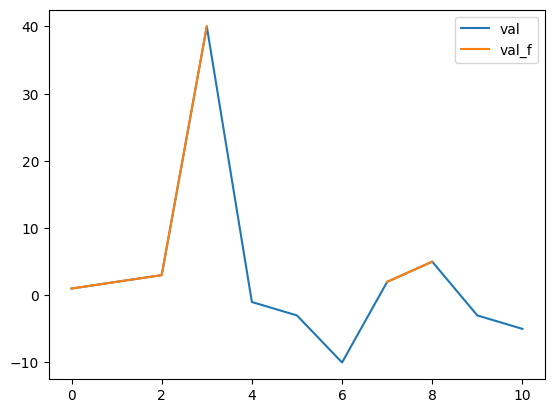

In [111]:
df_test = pd.DataFrame({"val":[1,2,3,40,-1,-3,-10,2,5,-3,-5]})
df_test["val_f"]=df_test["val"][df_test["val"] > 0]
df_test.plot()